In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import time as tm
from time import time
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde
import corner
from scipy.stats import norm

from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import Table, vstack
from glob import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score

The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
# pip install astroquery

In [12]:
paper_ready_catalog_1 = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/Prodosh_catolgue_full_data.fits'
wierd_cluster = "/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/wierd_cluster_from_kinematics.fits" 
                #this is a group selected from Prodosh's full catalogue. They have a simmilar position on the sky and form retrograde stucture in Energy vs Lz, and sqrt(Jr) vs Lz
Apogee_data = "/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/GC_members_VAC-v1_1.fits" 
                    #  this is from https://data.sdss.org/sas/dr17/env/APOGEE_GC/  and I found it thorugh
                    # "Monthly Notices of the Royal Astronomical Society, Volume 528, Issue 2, February 2024, 
                    #  Pages 1393–1407, https://doi.org/10.1093/mnras/stad3020"  
# matched_Apo_and_Perdosh = "NGC3201_Apo_and_Perdosh_match"
# matched__NGC0104_Apo_and_Perdosh = "NGC0104_Apo_p_prasosh_match"
All_Stars_Apo_p_prasosh_match = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/All_Stars_Apo_p_prasosh_match'

Closest_E_vs_Lz_to_NGC3201 = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/closest_E_vs_LZ_to_NGC3201'
Medium_E_vs_Lz_to_NGC3201 = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/Medium_E_vs_LZ_to_NGC3201'
Large_E_vs_Lz_to_NGC3201 = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/Large_E_vs_LZ_to_NGC3201'

def ensure_native_endian(df):
    """Convert all numeric NumPy columns in a DataFrame to native byte order."""
    for col in df.columns:
        dtype = df[col].dtype

        # Only handle real NumPy dtypes (skip pandas extension dtypes like StringDtype)
        if not isinstance(dtype, np.dtype):
            continue

        # Skip already-native or non-byte-order dtypes
        if dtype.byteorder in ('=', '|'):
            continue

        if np.issubdtype(dtype, np.number):
            df[col] = df[col].astype(dtype.newbyteorder('='))
    
    return df


In [13]:
with fitsio.FITS(paper_ready_catalog_1) as hdul1:
    data_full_1 = hdul1[1].read()
catofull = pd.DataFrame(data_full_1)
catofull = ensure_native_endian(catofull)

with fitsio.FITS(wierd_cluster) as hdul2:
    data_full_2 = hdul2[1].read()
NGC3201 = pd.DataFrame(data_full_2)
NGC3201 = ensure_native_endian(NGC3201)

with fitsio.FITS(Apogee_data) as hdul3:
    data_full_3 = hdul3[1].read()
    # Keep only columns that are truly 1D
    one_d_cols = [
        name for name in data_full_3.dtype.names
        if data_full_3[name].ndim == 1
    ]
    # Build a smaller structured array
    data_small_3 = data_full_3[one_d_cols]
Apogee = pd.DataFrame(data_small_3)
Apogee = ensure_native_endian(Apogee)
Apogee = Apogee[(Apogee['FE_H_FLAG'] == 0) & (Apogee['CA_FE_FLAG'] == 0 ) & (Apogee['SI_FE_FLAG'] == 0 ) & (Apogee['TI_FE_FLAG'] == 0 ) & (Apogee['NI_FE_FLAG'] == 0 ) 
                & (Apogee['CE_FE_FLAG'] == 0 )
                # & (Apogee['MEMBERFLAG'] != 0 ) # I dont know if this is a flag I should use. I dont really get if it being 0 is actually bad or not
                & (Apogee['STARFLAG'] == 0 )
                & (Apogee['ASPCAPFLAG'] == 0)
                # & (Apogee['SNREV'] > 70)
                # & (Apogee['TEFF'] > 3500)
                # & (Apogee['TEFF'] < 5500)
                ]

with fitsio.FITS(All_Stars_Apo_p_prasosh_match) as hdul4:
    data_full_4 = hdul4[1].read()
    # print(hdul4[1])
    # Keep only columns that are truly 1D
    one_d_cols = [
        name for name in data_full_4.dtype.names
        if data_full_4[name].ndim == 1
    ]
    # Build a smaller structured array
    data_small_4 = data_full_4[one_d_cols]
all_matched_Apo_p_Pradosh = pd.DataFrame(data_small_4)
all_matched_Apo_p_Pradosh = ensure_native_endian(all_matched_Apo_p_Pradosh)

NGC3201_matched = all_matched_Apo_p_Pradosh[(all_matched_Apo_p_Pradosh['GC_NAME'] == 'NGC3201')]
NGC0104_matched = all_matched_Apo_p_Pradosh[(all_matched_Apo_p_Pradosh['GC_NAME'] == 'NGC0104')]
NGC5139_matched = all_matched_Apo_p_Pradosh[(all_matched_Apo_p_Pradosh['GC_NAME'] == 'NGC5139')]
NGC6121_matched = all_matched_Apo_p_Pradosh[(all_matched_Apo_p_Pradosh['GC_NAME'] == 'NGC6121')]
NGC6254_matched = all_matched_Apo_p_Pradosh[(all_matched_Apo_p_Pradosh['GC_NAME'] == 'NGC6254')]

with fitsio.FITS(Closest_E_vs_Lz_to_NGC3201) as hdul6:
    data_full_6 = hdul6[1].read()
Closest_E_vs_Lz_to_NGC3201_data = pd.DataFrame(data_full_6)
Closest_E_vs_Lz_to_NGC3201_data = ensure_native_endian(Closest_E_vs_Lz_to_NGC3201_data)

with fitsio.FITS(Medium_E_vs_Lz_to_NGC3201) as hdul7:
    data_full_7 = hdul7[1].read()
Medium_E_vs_Lz_to_NGC3201_data = pd.DataFrame(data_full_7)
Medium_E_vs_Lz_to_NGC3201_data = ensure_native_endian(Medium_E_vs_Lz_to_NGC3201_data)
Medium_E_vs_Lz_to_NGC3201_data = Medium_E_vs_Lz_to_NGC3201_data[~Medium_E_vs_Lz_to_NGC3201_data['source_id'].isin(Closest_E_vs_Lz_to_NGC3201_data['source_id'])]

with fitsio.FITS(Large_E_vs_Lz_to_NGC3201) as hdul8:
    data_full_8 = hdul8[1].read()
Large_E_vs_Lz_to_NGC3201_data = pd.DataFrame(data_full_8)
Large_E_vs_Lz_to_NGC3201_data = ensure_native_endian(Large_E_vs_Lz_to_NGC3201_data)
Large_E_vs_Lz_to_NGC3201_data = Large_E_vs_Lz_to_NGC3201_data[(~Large_E_vs_Lz_to_NGC3201_data['source_id'].isin(Medium_E_vs_Lz_to_NGC3201_data['source_id'])) & (~Large_E_vs_Lz_to_NGC3201_data['source_id'].isin(Closest_E_vs_Lz_to_NGC3201_data['source_id']))]

In [14]:
flagged = catofull[catofull["flag_cannon"] == 0]
# flagged

Apo_NGC3201 = Apogee[(Apogee["GC_NAME"] == 'NGC3201')]
# Apo_NGC3201
list(Apo_NGC3201.columns)
len(Apo_NGC3201['GC_NAME'])

50

In [15]:
# Apo_NGC3201.to_csv('Apo_NGC3201.csv', sep=',', index=False)

In [16]:
chem_list = ["FeH", "CaFe", "SiFe", 'TiFe', 'NiFe', 'ZrFe', 'CeFe', 'NdFe']
chem_list_errors = ["e_FeH", "e_CaFe", "e_SiFe", 'e_TiFe', 'e_NiFe', 'e_ZrFe', 'e_CeFe', 'e_NdFe']

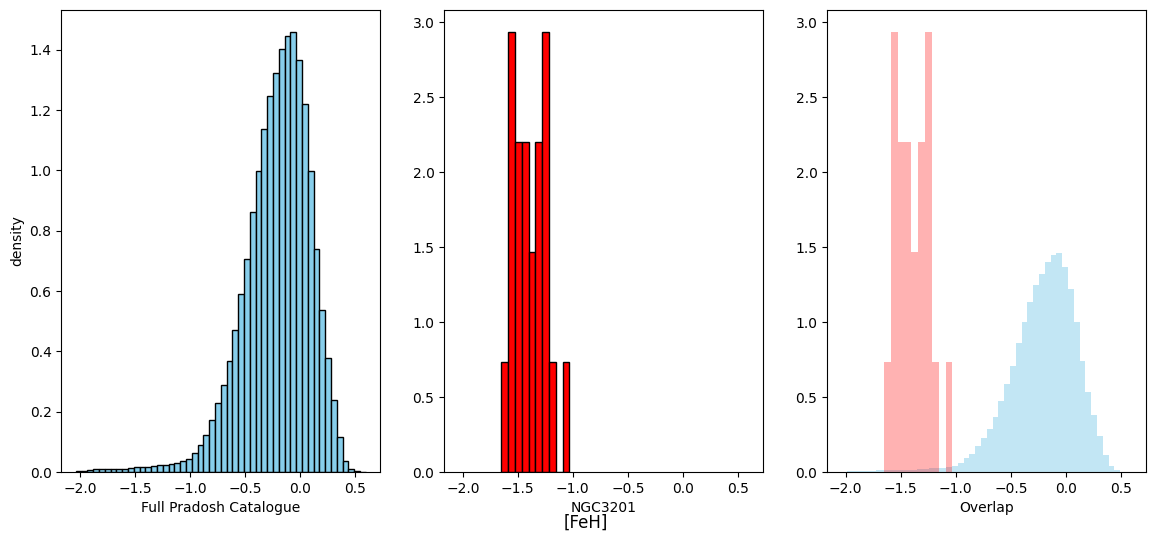

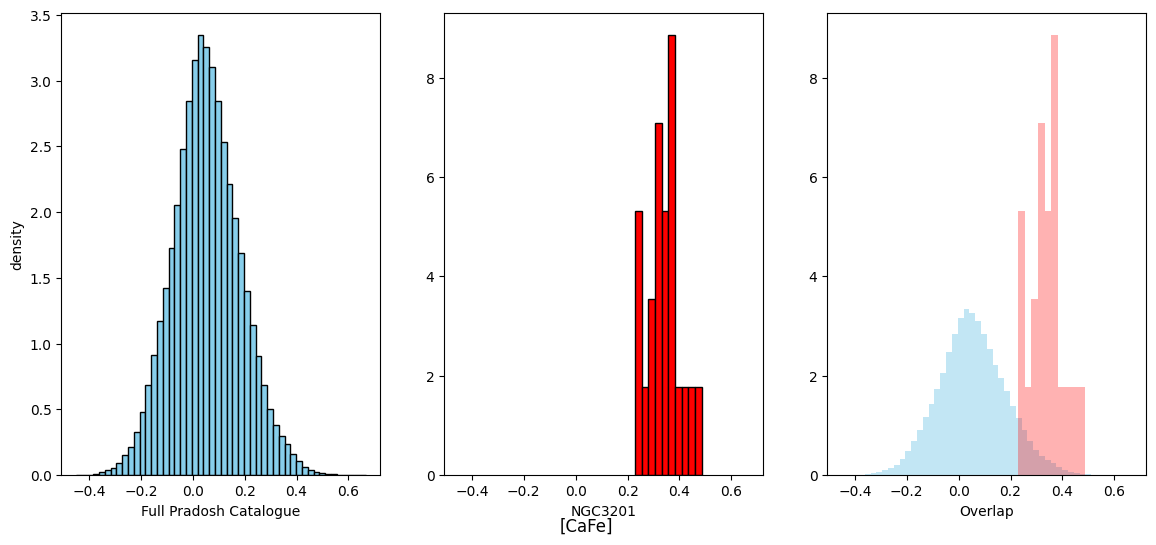

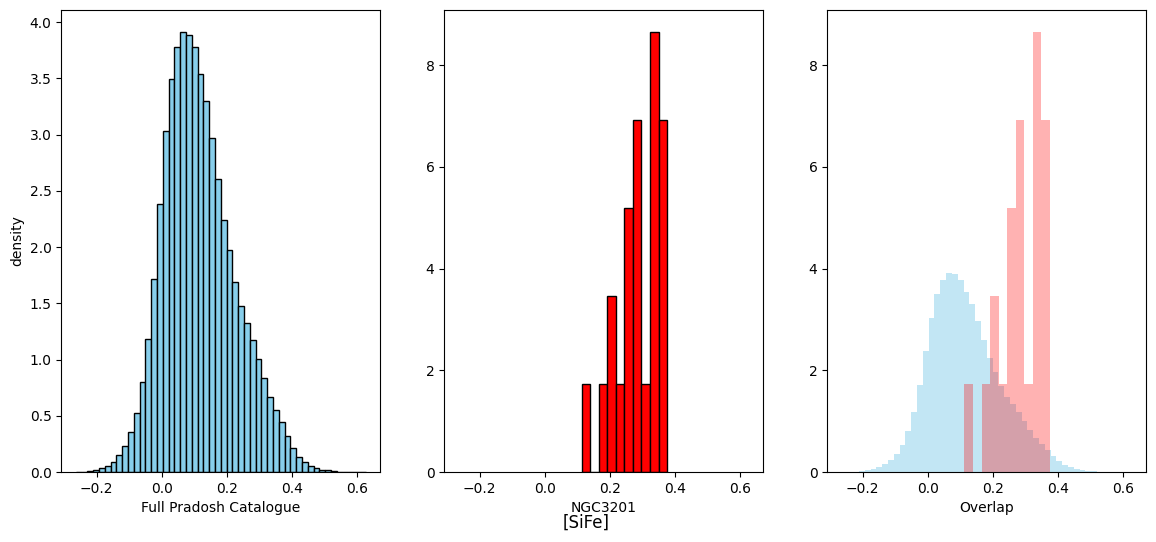

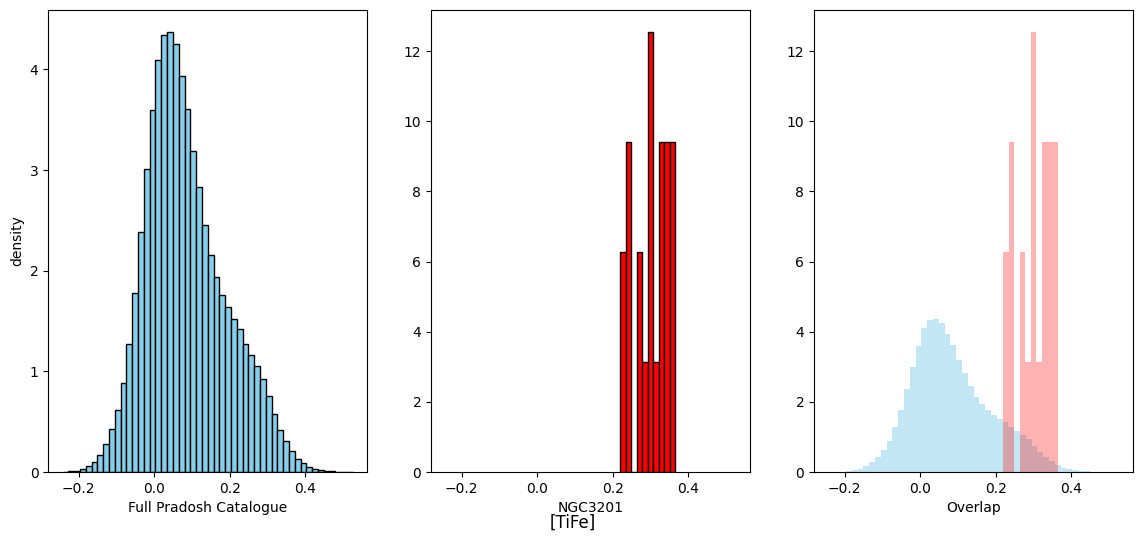

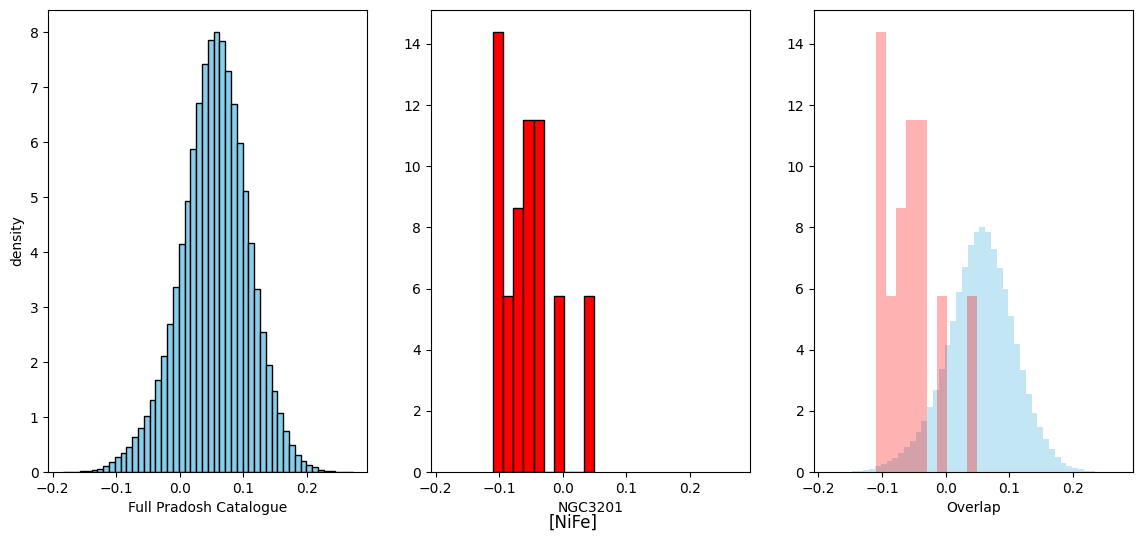

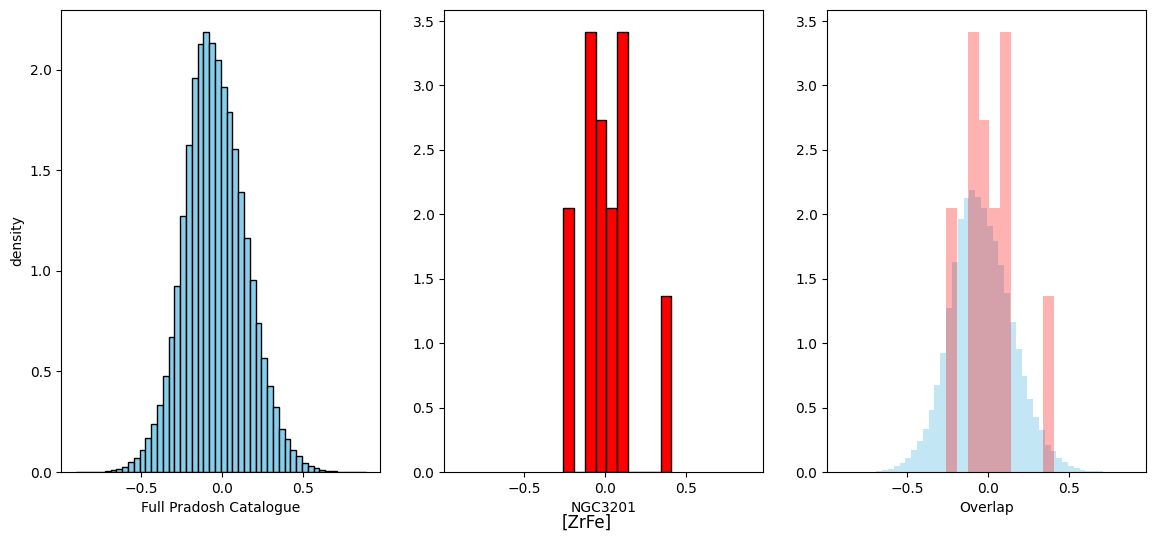

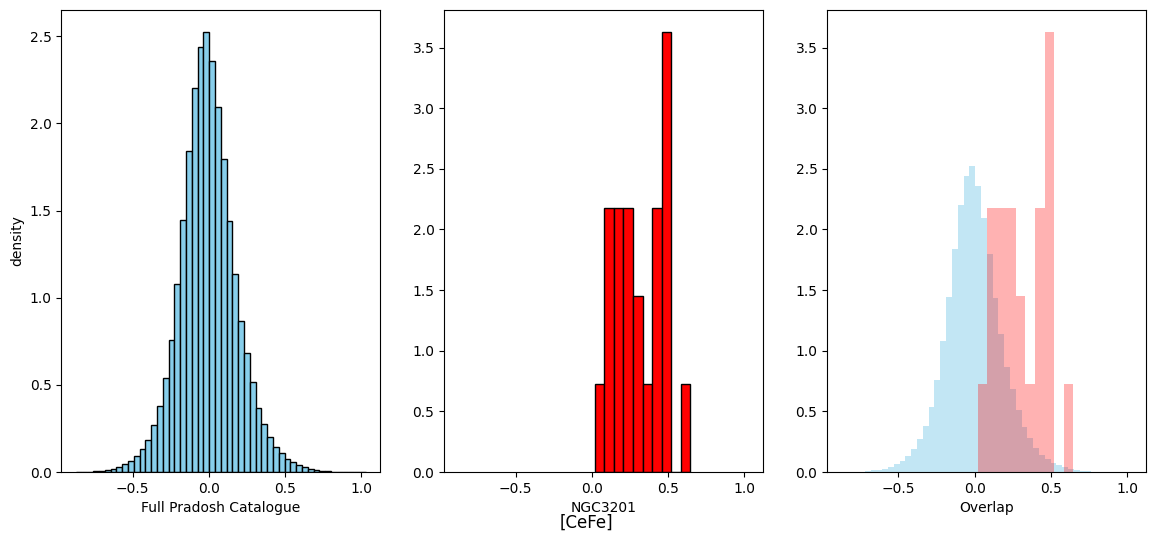

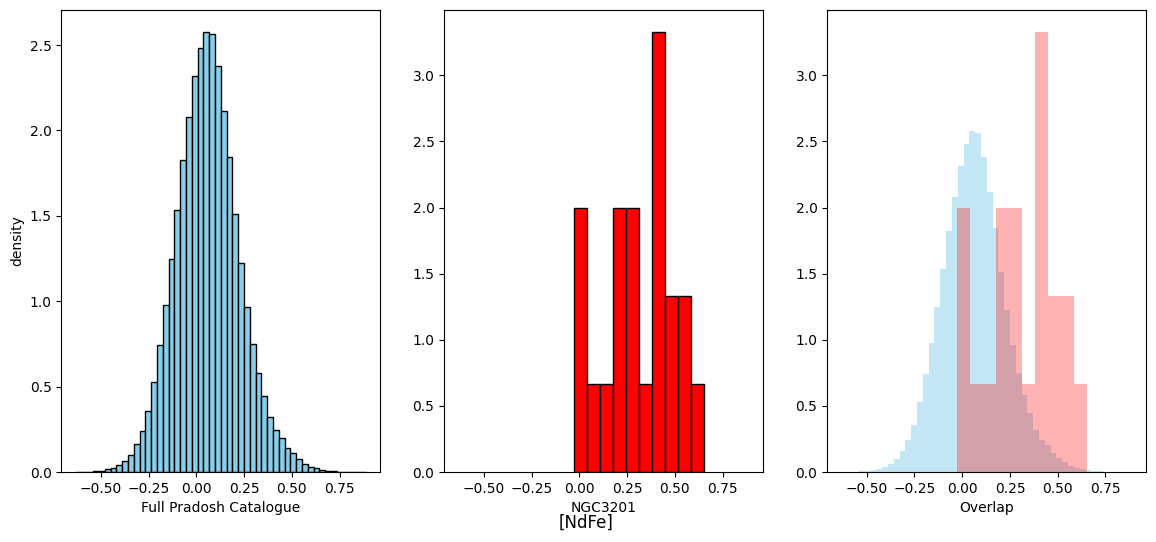

In [17]:
for i in chem_list:
    fig, ax = plt.subplots(1, 3, sharex=True, sharey=False, figsize=(14, 6)) # (rows, colums, share y axis and/or share x axis)
    ax[0].hist(flagged[i], bins=50,edgecolor = "black", density= True, color = "skyblue")
    ax[1].hist(NGC3201[i], bins=10,edgecolor = "black", density= True, color = "red")
    ax[2].hist(flagged[i], bins=50,edgecolor = "none", density= True, color = "skyblue", alpha = 0.5)
    ax[2].hist(NGC3201[i], bins=10,edgecolor = "none", density= True, color = "red", alpha = 0.3)
    ax[0].set_xlabel("Full Pradosh Catalogue")
    ax[1].set_xlabel("NGC3201")
    ax[2].set_xlabel("Overlap")
    fig.supxlabel(F"[{i}]")
    # fig.supylabel("density")
    ax[0].set_ylabel("density")
   

Text(0.5, 1.0, 'NGC3201 Stars')

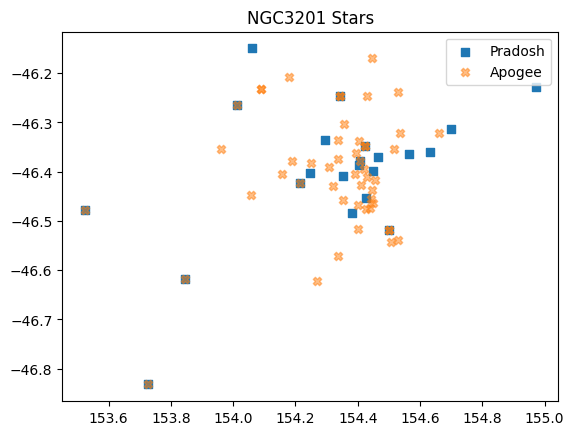

In [18]:
plt.scatter(NGC3201["RA"], NGC3201["DEC"], marker='s', label = "Pradosh")
plt.scatter(Apo_NGC3201['RA'], Apo_NGC3201['DEC'], alpha = 0.5, marker='X', label = "Apogee")

plt.legend()
plt.title("NGC3201 Stars")

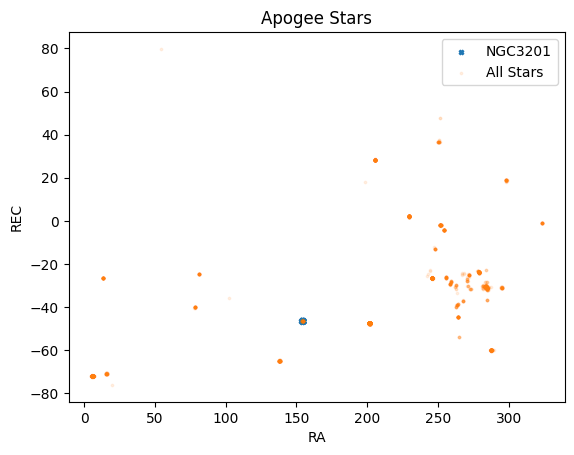

In [19]:
plt.scatter(Apo_NGC3201['RA'], Apo_NGC3201['DEC'], marker='X', s = 10, label = "NGC3201")
plt.scatter(Apogee['RA'], Apogee['DEC'], alpha = 0.1, s = 3, label = "All Stars")
plt.xlabel("RA")
plt.ylabel("REC")
plt.title("Apogee Stars")
plt.legend()

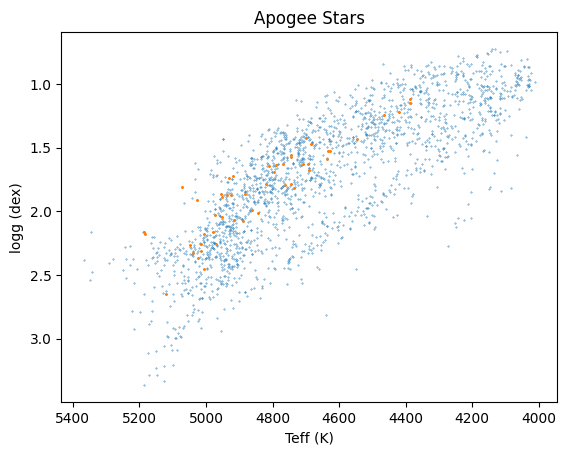

In [20]:
plt.scatter(Apogee['TEFF'], Apogee['LOGG'],  s = 0.1,) #c = Apogee["FE_H"], cmap = "managua_r") #, vmin = -3, vmax = 2 )
plt.scatter(Apo_NGC3201['TEFF'], Apo_NGC3201['LOGG'], s = 1, marker = 'X')

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

plt.xlabel("Teff (K)")
plt.ylabel("logg (dex)")
# plt.colorbar( label = "[Fe_H]")
plt.title("Apogee Stars");

Text(0, 0.5, 'density')

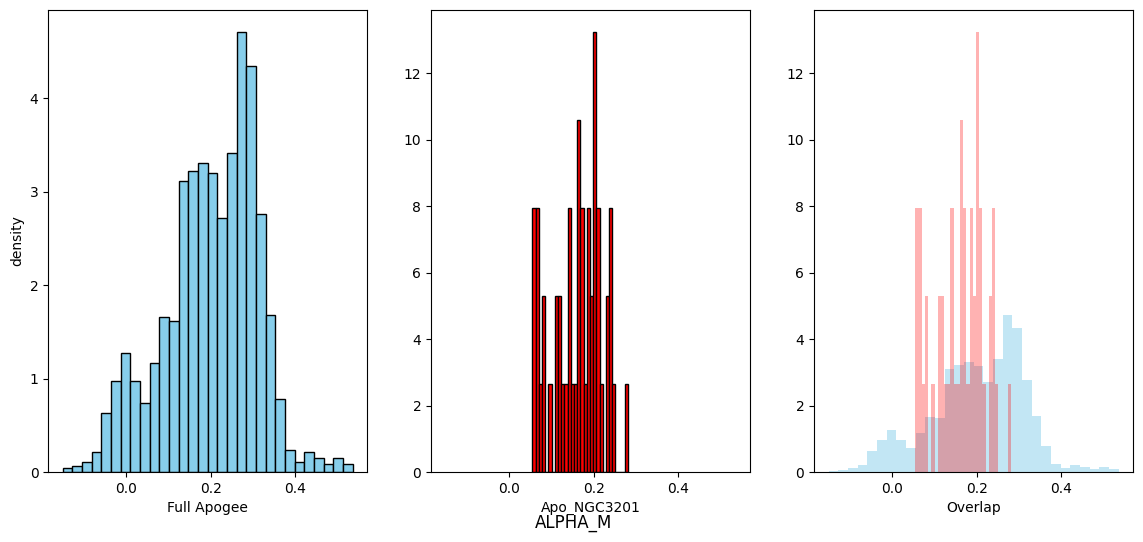

In [21]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=False, figsize=(14, 6)) # (rows, colums, share y axis and/or share x axis)
ax[0].hist(Apogee['ALPHA_M'], bins=30,edgecolor = "black", density= True, color = "skyblue")
ax[1].hist(Apo_NGC3201['ALPHA_M'], bins=30,edgecolor = "black", density= True, color = "red")
ax[2].hist(Apogee['ALPHA_M'], bins=30,edgecolor = "none", density= True, color = "skyblue", alpha = 0.5)
ax[2].hist(Apo_NGC3201['ALPHA_M'], bins=30,edgecolor = "none", density= True, color = "red", alpha = 0.3)
ax[0].set_xlabel("Full Apogee")
ax[1].set_xlabel("Apo_NGC3201")
ax[2].set_xlabel("Overlap")
fig.supxlabel('ALPHA_M')
# fig.supylabel("density")
ax[0].set_ylabel("density")

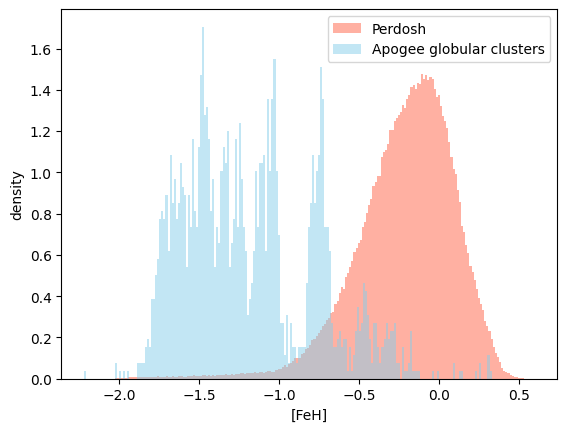

In [22]:
plt.hist(flagged['FeH'], bins = 200, density= True, color = "tomato", alpha = 0.5, label = "Perdosh")
plt.hist(Apogee['FE_H'],bins = 200, density= True, color = "skyblue", alpha = 0.5, label = "Apogee globular clusters");

plt.xlabel("[FeH]")
plt.ylabel("density")
plt.legend()

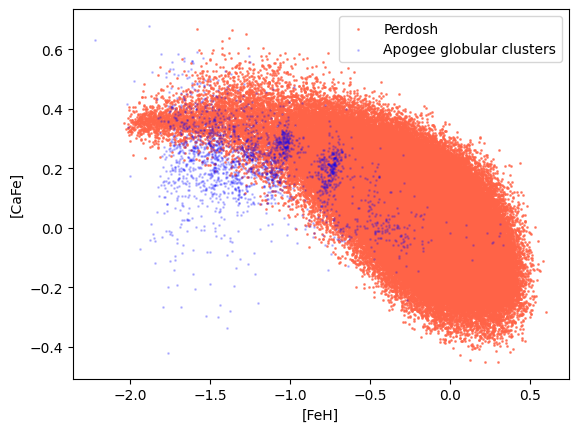

In [23]:
plt.scatter(flagged['FeH'], flagged['CaFe'], color = "tomato", alpha = 0.7, label = "Perdosh", s = 1)
plt.scatter(Apogee['FE_H'], Apogee["CA_FE"], color = "blue", alpha = 0.2, label = "Apogee globular clusters", s = 1);

plt.xlabel("[FeH]")
plt.ylabel("[CaFe]")
plt.legend()


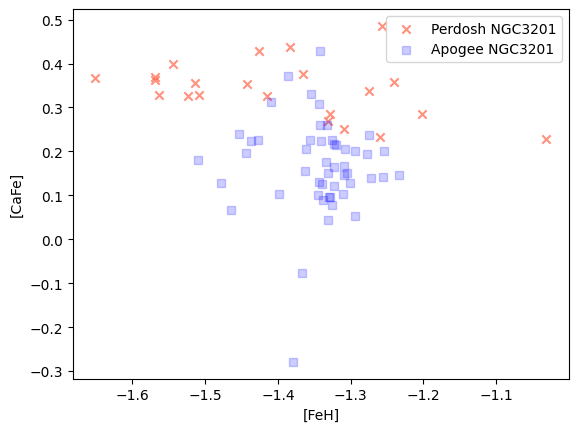

In [24]:
plt.scatter(NGC3201['FeH'], NGC3201['CaFe'], color = "tomato", alpha = 0.7, label = "Perdosh NGC3201", marker='x' )
plt.scatter(Apo_NGC3201['FE_H'], Apo_NGC3201["CA_FE"], color = "blue", alpha = 0.2, label = "Apogee NGC3201", marker='s');

plt.xlabel("[FeH]")
plt.ylabel("[CaFe]")
plt.legend()

Text(0, 0.5, 'Density vs [CeFe]')

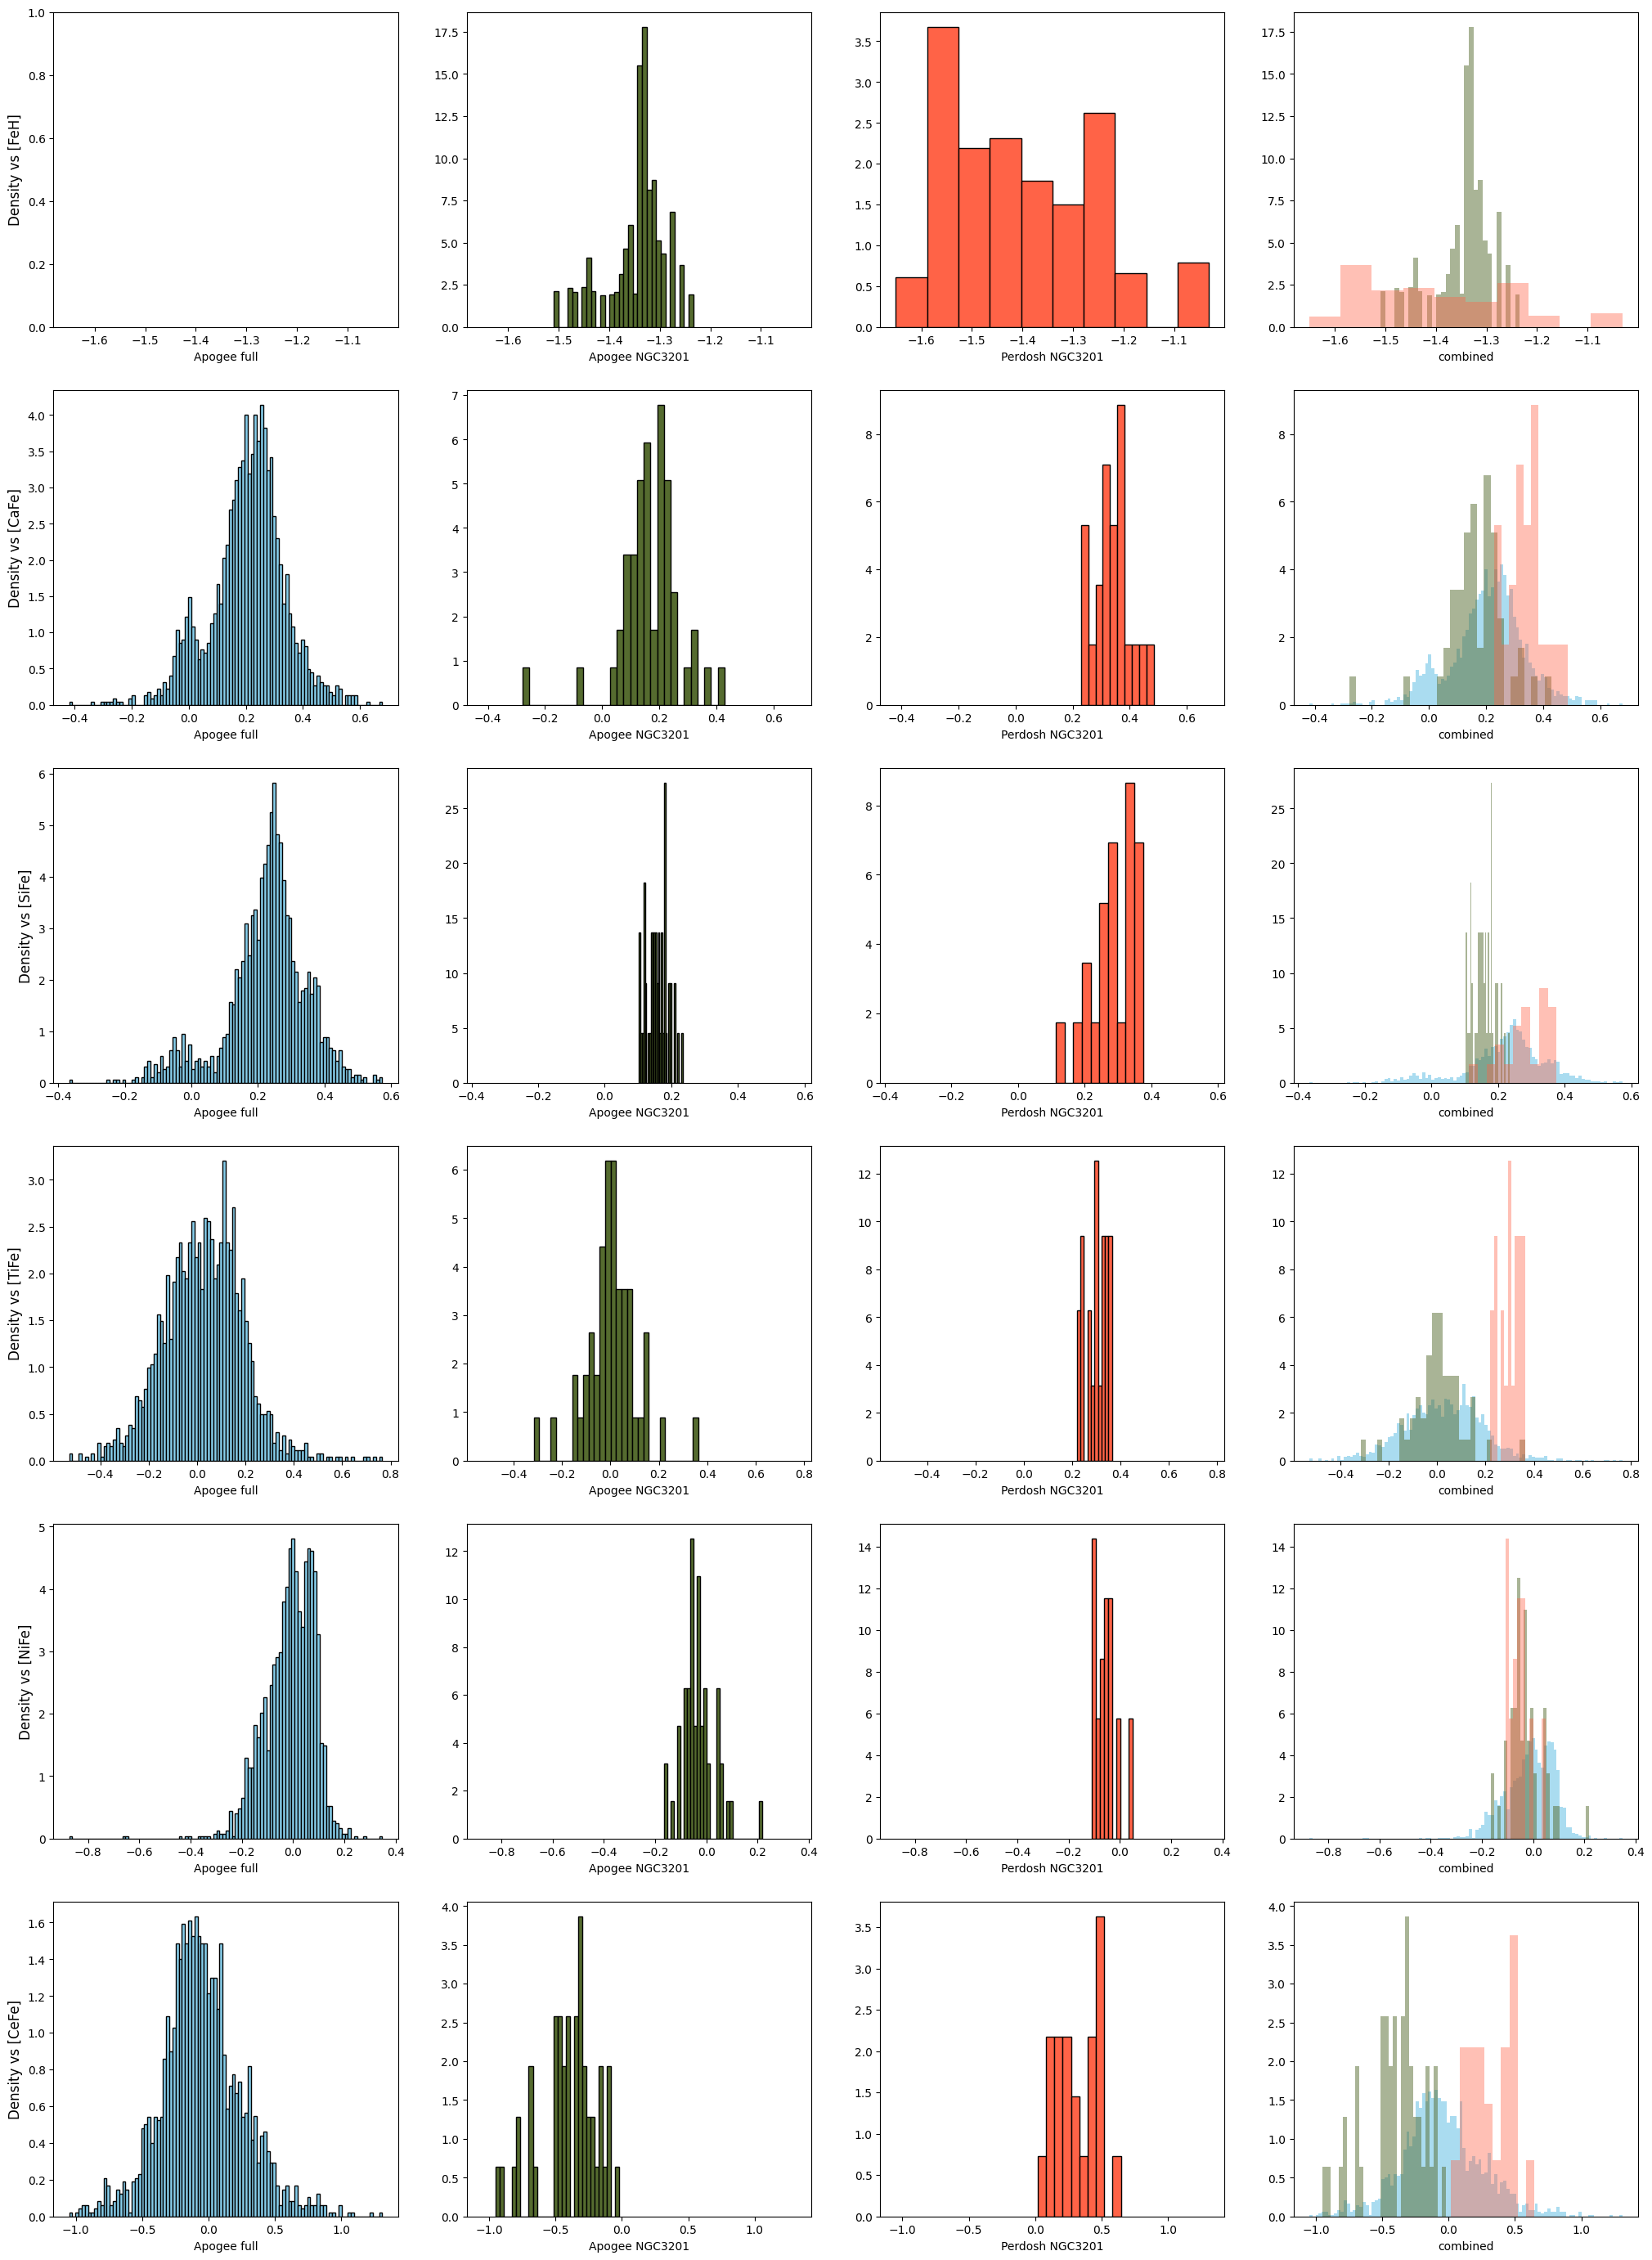

In [25]:
fig, ax = plt.subplots(6, 4, sharex='row', sharey=False, figsize=(25, 35)) # (rows, colums, share y axis and/or share x axis)
                                                                           # I used (25, 50) for the figsixe when all 8 of Perdosh's elements were added, and (25,35) when only 6 are used
bins1 = 100
bins2 = 30
bins3 = 10

# ax[0,0].hist(Apogee['FE_H'], bins= bins1, edgecolor = "black", density= True, color = "skyblue")
ax[0,1].hist(Apo_NGC3201['FE_H'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen", weights = Apo_NGC3201['FE_H_ERR'])
ax[0,2].hist(NGC3201['FeH'], bins=bins3, edgecolor = "black", density= True, color = "tomato", weights = NGC3201['e_FeH'])
# ax[0,3].hist(Apogee['FE_H'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
ax[0,3].hist(Apo_NGC3201['FE_H'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5, weights = Apo_NGC3201['FE_H_ERR'])
ax[0,3].hist(NGC3201['FeH'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4, weights = NGC3201['e_FeH'])
ax[0,0].set_xlabel('Apogee full', fontsize=10)
ax[0,1].set_xlabel('Apogee NGC3201', fontsize=10)
ax[0,2].set_xlabel('Perdosh NGC3201', fontsize=10)
ax[0,3].set_xlabel('combined', fontsize=10)

ax[1,0].hist(Apogee['CA_FE'], bins=bins1, edgecolor = "black", density= True, color = "skyblue")
ax[1,1].hist(Apo_NGC3201['CA_FE'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen")
ax[1,2].hist(NGC3201['CaFe'], bins=bins3, edgecolor = "black", density= True, color = "tomato")
ax[1,3].hist(Apogee['CA_FE'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
ax[1,3].hist(Apo_NGC3201['CA_FE'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5)
ax[1,3].hist(NGC3201['CaFe'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4)
ax[1,0].set_xlabel('Apogee full', fontsize=10)
ax[1,1].set_xlabel('Apogee NGC3201', fontsize=10)
ax[1,2].set_xlabel('Perdosh NGC3201', fontsize=10)
ax[1,3].set_xlabel('combined', fontsize=10)

ax[2,0].hist(Apogee['SI_FE'], bins=bins1, edgecolor = "black", density= True, color = "skyblue")
ax[2,1].hist(Apo_NGC3201['SI_FE'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen")
ax[2,2].hist(NGC3201['SiFe'], bins=bins3, edgecolor = "black", density= True, color = "tomato")
ax[2,3].hist(Apogee['SI_FE'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
ax[2,3].hist(Apo_NGC3201['SI_FE'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5)
ax[2,3].hist(NGC3201['SiFe'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4)
ax[2,0].set_xlabel('Apogee full', fontsize=10)
ax[2,1].set_xlabel('Apogee NGC3201', fontsize=10)
ax[2,2].set_xlabel('Perdosh NGC3201', fontsize=10)
ax[2,3].set_xlabel('combined', fontsize=10)

ax[3,0].hist(Apogee['TI_FE'], bins=bins1, edgecolor = "black", density= True, color = "skyblue")
ax[3,1].hist(Apo_NGC3201['TI_FE'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen")
ax[3,2].hist(NGC3201['TiFe'], bins=bins3, edgecolor = "black", density= True, color = "tomato")
ax[3,3].hist(Apogee['TI_FE'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
ax[3,3].hist(Apo_NGC3201['TI_FE'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5)
ax[3,3].hist(NGC3201['TiFe'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4)
ax[3,0].set_xlabel('Apogee full', fontsize=10)
ax[3,1].set_xlabel('Apogee NGC3201', fontsize=10)
ax[3,2].set_xlabel('Perdosh NGC3201', fontsize=10)
ax[3,3].set_xlabel('combined', fontsize=10)

ax[4,0].hist(Apogee['NI_FE'], bins=bins1, edgecolor = "black", density= True, color = "skyblue")
ax[4,1].hist(Apo_NGC3201['NI_FE'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen")
ax[4,2].hist(NGC3201['NiFe'], bins=bins3, edgecolor = "black", density= True, color = "tomato")
ax[4,3].hist(Apogee['NI_FE'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
ax[4,3].hist(Apo_NGC3201['NI_FE'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5)
ax[4,3].hist(NGC3201['NiFe'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4)
ax[4,0].set_xlabel('Apogee full', fontsize=10)
ax[4,1].set_xlabel('Apogee NGC3201', fontsize=10)
ax[4,2].set_xlabel('Perdosh NGC3201', fontsize=10)
ax[4,3].set_xlabel('combined', fontsize=10)

# ax[5,0].hist(Apogee['ZR_FE'], bins=bins1, edgecolor = "black", density= True, color = "skyblue")
# ax[5,1].hist(Apo_NGC3201['ZR_FE'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen")
# ax[5,2].hist(NGC3201['ZrFe'], bins=bins3, edgecolor = "black", density= True, color = "tomato")
# ax[5,3].hist(Apogee['ZR_FE'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
# ax[5,3].hist(Apo_NGC3201['ZR_FE'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5)
# ax[5,3].hist(NGC3201['ZrFe'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4)
# ax[5,0].set_xlabel('Apogee full', fontsize=10)
# ax[5,1].set_xlabel('Apogee NGC3201', fontsize=10)
# ax[5,2].set_xlabel('Perdosh NGC3201', fontsize=10)
# ax[5,3].set_xlabel('combined', fontsize=10)

ax[5,0].hist(Apogee['CE_FE'], bins=bins1, edgecolor = "black", density= True, color = "skyblue") #I numbered these in the order of increasing atomic number. However Apogee did not check Zr. So Zr would be 5 but now Ce is.
ax[5,1].hist(Apo_NGC3201['CE_FE'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen")
ax[5,2].hist(NGC3201['CeFe'], bins=bins3, edgecolor = "black", density= True, color = "tomato")
ax[5,3].hist(Apogee['CE_FE'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
ax[5,3].hist(Apo_NGC3201['CE_FE'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5)
ax[5,3].hist(NGC3201['CeFe'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4)
ax[5,0].set_xlabel('Apogee full', fontsize=10)
ax[5,1].set_xlabel('Apogee NGC3201', fontsize=10)
ax[5,2].set_xlabel('Perdosh NGC3201', fontsize=10)
ax[5,3].set_xlabel('combined', fontsize=10)

# ax[7,0].hist(Apogee['ND_FE'], bins=bins1, edgecolor = "black", density= True, color = "skyblue")
# ax[7,1].hist(Apo_NGC3201['ND_FE'], bins=bins2, edgecolor = "black", density= True, color = "darkolivegreen")
# ax[7,2].hist(NGC3201['NdFe'], bins=bins3, edgecolor = "black", density= True, color = "tomato")
# ax[7,3].hist(Apogee['ND_FE'], bins=bins1, edgecolor = "none", density= True, color = "skyblue", alpha = 0.7)
# ax[7,3].hist(Apo_NGC3201['ND_FE'], bins=bins2, edgecolor = "none", density= True, color = "darkolivegreen", alpha = .5)
# ax[7,3].hist(NGC3201['NdFe'], bins=bins3, edgecolor = "none", density= True, color = "tomato", alpha = 0.4)
# ax[7,0].set_xlabel('Apogee full', fontsize=10)
# ax[7,1].set_xlabel('Apogee NGC3201', fontsize=10)
# ax[7,2].set_xlabel('Perdosh NGC3201', fontsize=10)
# ax[7,3].set_xlabel('combined', fontsize=10)


ax[0,0].set_ylabel('Density vs [FeH]', fontsize=12)
ax[1,0].set_ylabel('Density vs [CaFe]', fontsize=12)
ax[2,0].set_ylabel('Density vs [SiFe]', fontsize=12)
ax[3,0].set_ylabel('Density vs [TiFe]', fontsize=12)
ax[4,0].set_ylabel('Density vs [NiFe]', fontsize=12)
# ax[5,0].set_ylabel('Density vs [ZrFe]', fontsize=12)
ax[5,0].set_ylabel('Density vs [CeFe]', fontsize=12)
# ax[7,0].set_ylabel('Density vs [NdFe]', fontsize=12)



Text(0, 0.5, 'Density vs [CeFe]')

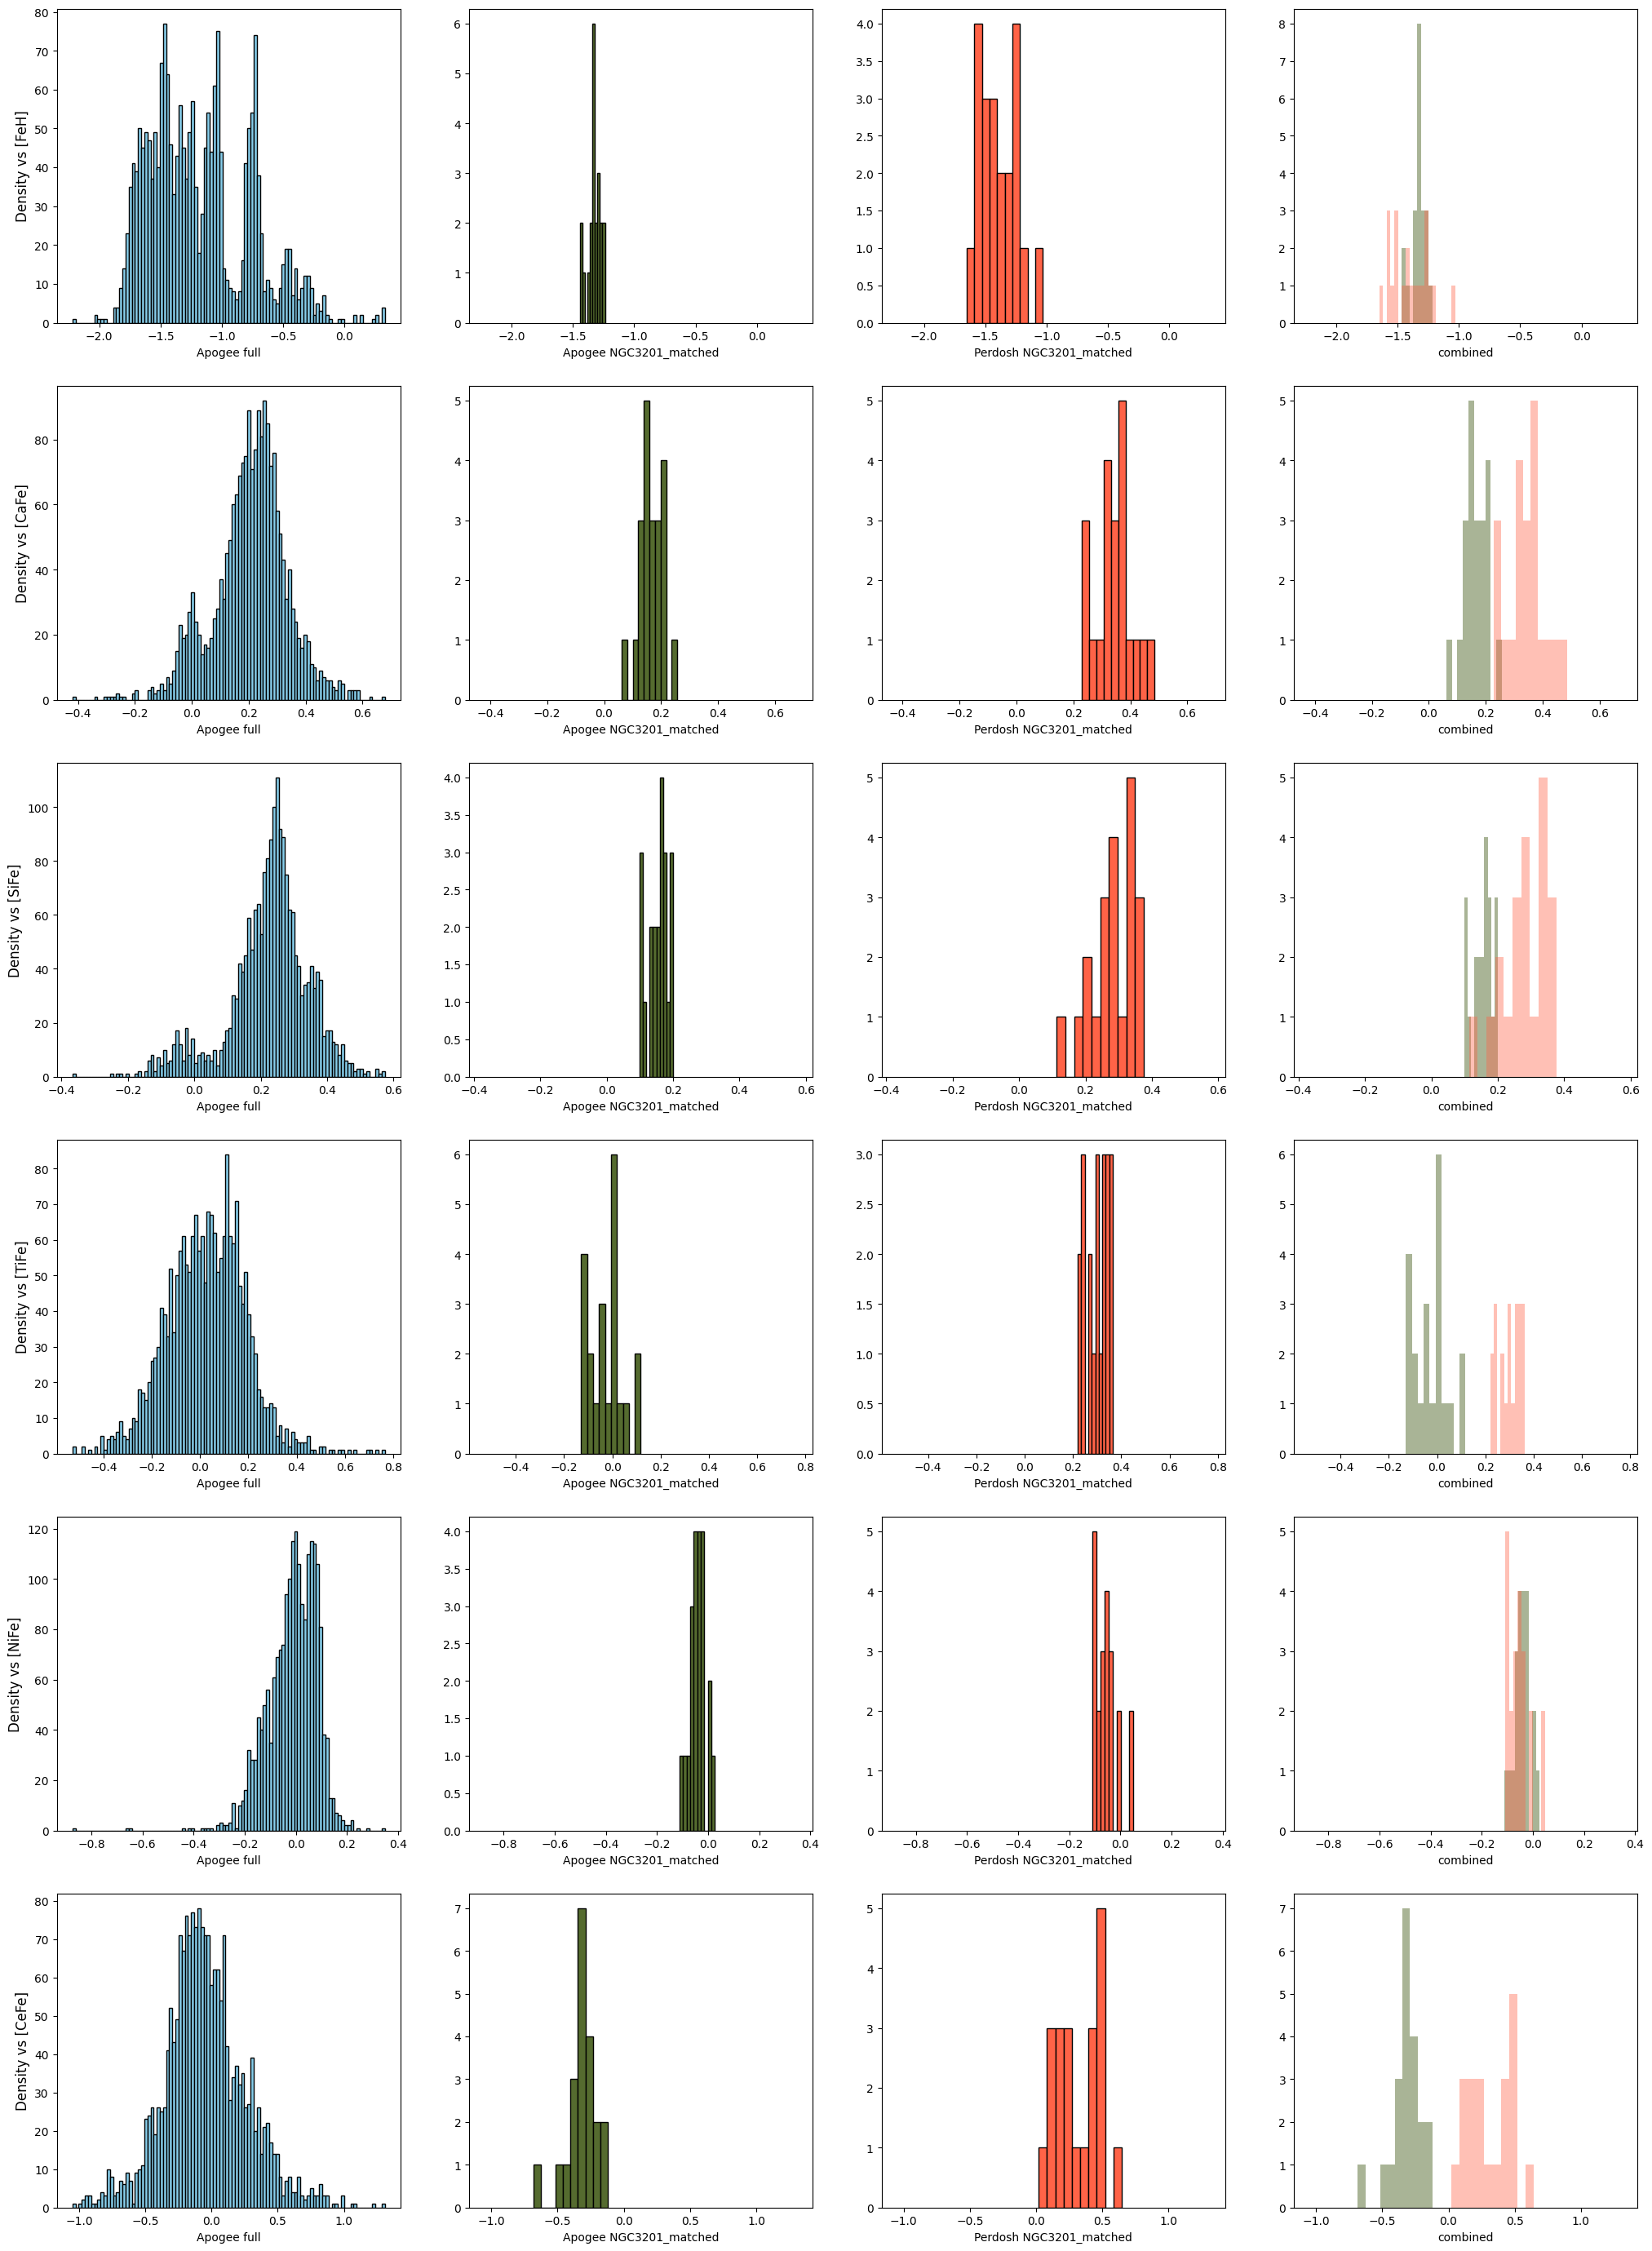

In [26]:
fig, ax = plt.subplots(6, 4, sharex='row', sharey=False, figsize=(25, 35)) # (rows, colums, share y axis and/or share x axis)
                                                                           # I used (25, 50) for the figsixe when all 8 of Perdosh's elements were added, and (25,35) when only 6 are used
bins1 = 100
bins2 = 10
bins3 = 10

ax[0,0].hist(Apogee['FE_H'], bins= bins1, edgecolor = "black", density = False, color = "skyblue")
ax[0,1].hist(NGC3201_matched['FE_H'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
ax[0,2].hist(NGC3201_matched['FeH'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[0,3].hist(Apogee['FE_H'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
fe1 = NGC3201_matched['FE_H'].dropna()
fe2 = NGC3201_matched['FeH'].dropna()

bins_fe = np.histogram_bin_edges(
    np.concatenate([fe1, fe2]),
    bins=20
)

ax[0,3].hist(fe1, bins=bins_fe, edgecolor="none",
             color="darkolivegreen", alpha=0.5)
ax[0,3].hist(fe2, bins=bins_fe, edgecolor="none",
             color="tomato", alpha=0.4)
ax[0,0].set_xlabel('Apogee full', fontsize=10)
ax[0,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
ax[0,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
ax[0,3].set_xlabel('combined', fontsize=10)

ax[1,0].hist(Apogee['CA_FE'], bins=bins1, edgecolor = "black", density = False, color = "skyblue")
ax[1,1].hist(NGC3201_matched['CA_FE'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
ax[1,2].hist(NGC3201_matched['CaFe'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[1,3].hist(Apogee['CA_FE'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
ax[1,3].hist(NGC3201_matched['CA_FE'], bins=bins2, edgecolor = "none", density = False, color = "darkolivegreen", alpha = .5)
ax[1,3].hist(NGC3201_matched['CaFe'], bins=bins3, edgecolor = "none", density = False, color = "tomato", alpha = 0.4)
ax[1,0].set_xlabel('Apogee full', fontsize=10)
ax[1,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
ax[1,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
ax[1,3].set_xlabel('combined', fontsize=10)

ax[2,0].hist(Apogee['SI_FE'], bins=bins1, edgecolor = "black", density = False, color = "skyblue")
ax[2,1].hist(NGC3201_matched['SI_FE'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
ax[2,2].hist(NGC3201_matched['SiFe'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[2,3].hist(Apogee['SI_FE'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
ax[2,3].hist(NGC3201_matched['SI_FE'], bins=bins2, edgecolor = "none", density = False, color = "darkolivegreen", alpha = .5)
ax[2,3].hist(NGC3201_matched['SiFe'], bins=bins3, edgecolor = "none", density = False, color = "tomato", alpha = 0.4)
ax[2,0].set_xlabel('Apogee full', fontsize=10)
ax[2,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
ax[2,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
ax[2,3].set_xlabel('combined', fontsize=10)

ax[3,0].hist(Apogee['TI_FE'], bins=bins1, edgecolor = "black", density = False, color = "skyblue")
ax[3,1].hist(NGC3201_matched['TI_FE'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
ax[3,2].hist(NGC3201_matched['TiFe'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[3,3].hist(Apogee['TI_FE'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
ax[3,3].hist(NGC3201_matched['TI_FE'], bins=bins2, edgecolor = "none", density = False, color = "darkolivegreen", alpha = .5)
ax[3,3].hist(NGC3201_matched['TiFe'], bins=bins3, edgecolor = "none", density = False, color = "tomato", alpha = 0.4)
ax[3,0].set_xlabel('Apogee full', fontsize=10)
ax[3,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
ax[3,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
ax[3,3].set_xlabel('combined', fontsize=10)

ax[4,0].hist(Apogee['NI_FE'], bins=bins1, edgecolor = "black", density = False, color = "skyblue")
ax[4,1].hist(NGC3201_matched['NI_FE'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
ax[4,2].hist(NGC3201_matched['NiFe'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[4,3].hist(Apogee['NI_FE'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
ax[4,3].hist(NGC3201_matched['NI_FE'], bins=bins2, edgecolor = "none", density = False, color = "darkolivegreen", alpha = .5)
ax[4,3].hist(NGC3201_matched['NiFe'], bins=bins3, edgecolor = "none", density = False, color = "tomato", alpha = 0.4)
ax[4,0].set_xlabel('Apogee full', fontsize=10)
ax[4,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
ax[4,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
ax[4,3].set_xlabel('combined', fontsize=10)

# ax[5,0].hist(Apogee['ZR_FE'], bins=bins1, edgecolor = "black", density = False, color = "skyblue")
# ax[5,1].hist(NGC3201_matched['ZR_FE'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
# ax[5,2].hist(NGC3201_matched['ZrFe'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[5,3].hist(Apogee['ZR_FE'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
# ax[5,3].hist(NGC3201_matched['ZR_FE'], bins=bins2, edgecolor = "none", density = False, color = "darkolivegreen", alpha = .5)
# ax[5,3].hist(NGC3201_matched['ZrFe'], bins=bins3, edgecolor = "none", density = False, color = "tomato", alpha = 0.4)
# ax[5,0].set_xlabel('Apogee full', fontsize=10)
# ax[5,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
# ax[5,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
# ax[5,3].set_xlabel('combined', fontsize=10)

ax[5,0].hist(Apogee['CE_FE'], bins=bins1, edgecolor = "black", density = False, color = "skyblue") #I numbered these in the order of increasing atomic number. However Apogee did not check Zr. So Zr would be 5 but now Ce is.
ax[5,1].hist(NGC3201_matched['CE_FE'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
ax[5,2].hist(NGC3201_matched['CeFe'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[5,3].hist(Apogee['CE_FE'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
ax[5,3].hist(NGC3201_matched['CE_FE'], bins=bins2, edgecolor = "none", density = False, color = "darkolivegreen", alpha = .5)
ax[5,3].hist(NGC3201_matched['CeFe'], bins=bins3, edgecolor = "none", density = False, color = "tomato", alpha = 0.4)
ax[5,0].set_xlabel('Apogee full', fontsize=10)
ax[5,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
ax[5,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
ax[5,3].set_xlabel('combined', fontsize=10)

# ax[7,0].hist(Apogee['ND_FE'], bins=bins1, edgecolor = "black", density = False, color = "skyblue")
# ax[7,1].hist(NGC3201_matched['ND_FE'], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
# ax[7,2].hist(NGC3201_matched['NdFe'], bins=bins3, edgecolor = "black", density = False, color = "tomato")
# ax[7,3].hist(Apogee['ND_FE'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)
# ax[7,3].hist(NGC3201_matched['ND_FE'], bins=bins2, edgecolor = "none", density = False, color = "darkolivegreen", alpha = .5)
# ax[7,3].hist(NGC3201_matched['NdFe'], bins=bins3, edgecolor = "none", density = False, color = "tomato", alpha = 0.4)
# ax[7,0].set_xlabel('Apogee full', fontsize=10)
# ax[7,1].set_xlabel('Apogee NGC3201_matched', fontsize=10)
# ax[7,2].set_xlabel('Perdosh NGC3201_matched', fontsize=10)
# ax[7,3].set_xlabel('combined', fontsize=10)


ax[0,0].set_ylabel('Density vs [FeH]', fontsize=12)
ax[1,0].set_ylabel('Density vs [CaFe]', fontsize=12)
ax[2,0].set_ylabel('Density vs [SiFe]', fontsize=12)
ax[3,0].set_ylabel('Density vs [TiFe]', fontsize=12)
ax[4,0].set_ylabel('Density vs [NiFe]', fontsize=12)
# ax[5,0].set_ylabel('Density vs [ZrFe]', fontsize=12)
ax[5,0].set_ylabel('Density vs [CeFe]', fontsize=12)
# ax[7,0].set_ylabel('Density vs [NdFe]', fontsize=12)

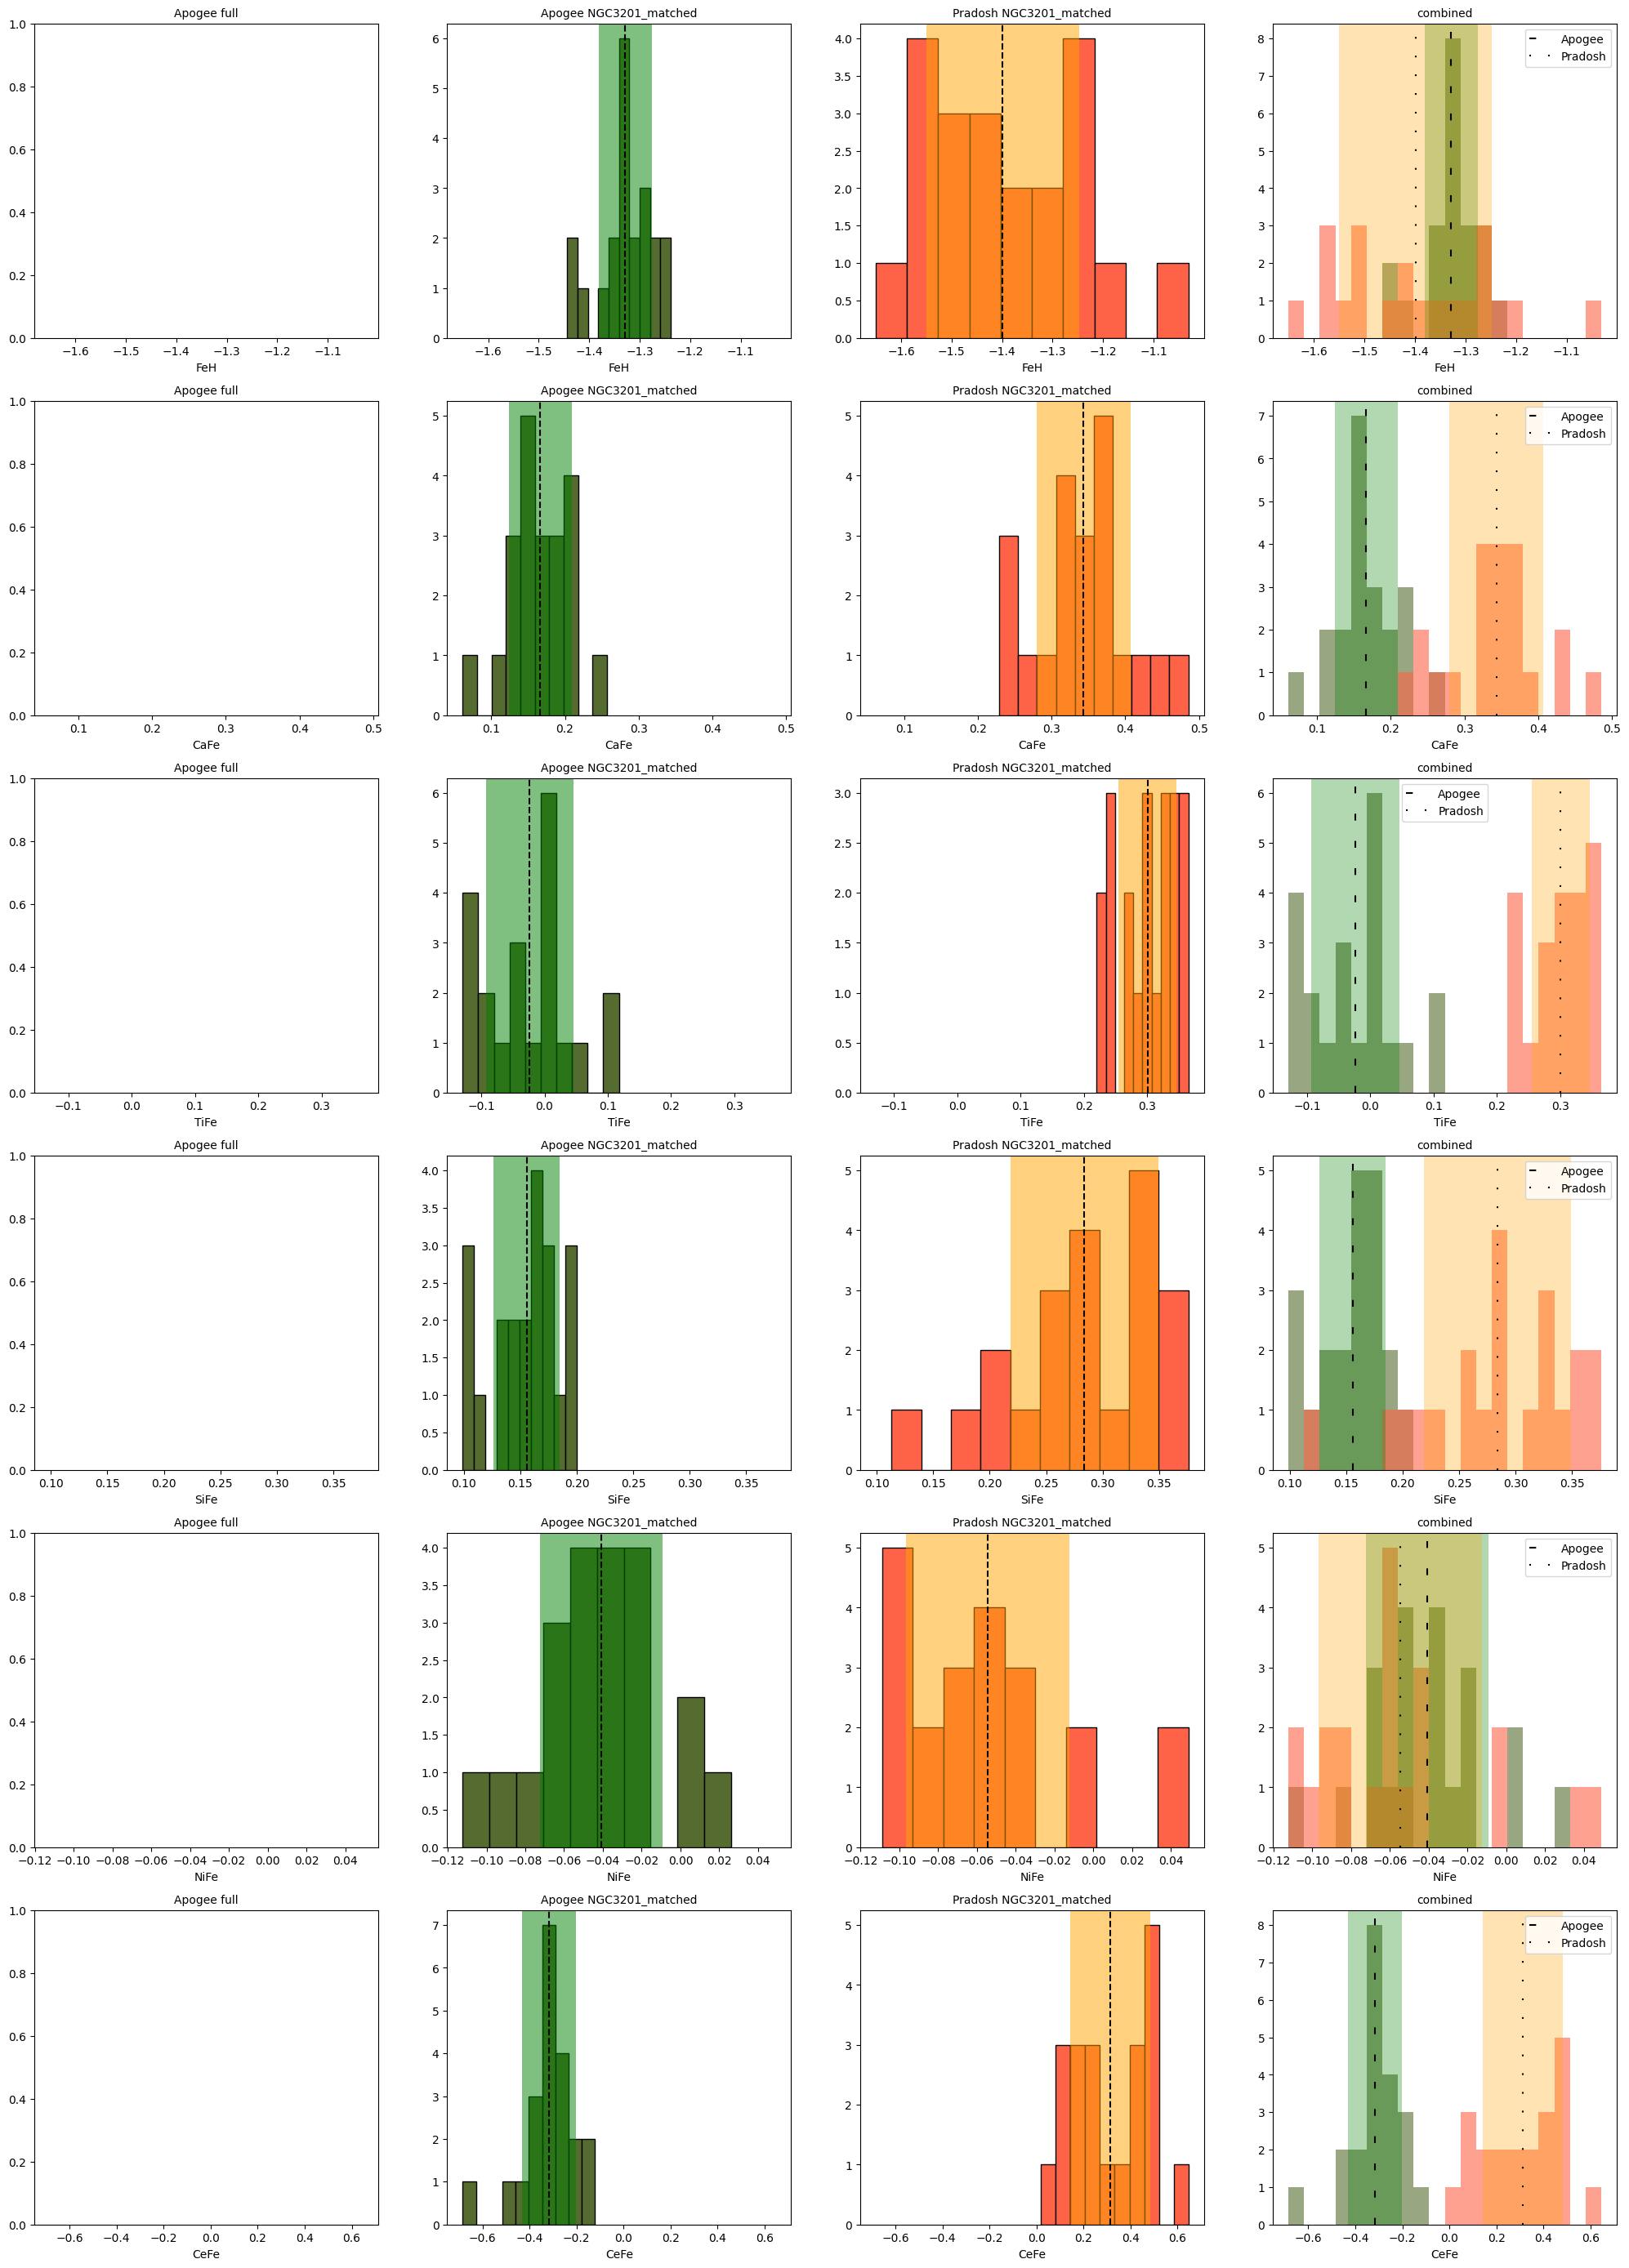

In [27]:
def histograms(labels, Apogee, NGC3201_matched):
    fig, ax = plt.subplots(len(labels), 4, sharex='row', sharey=False, figsize=(25, 35))
    for i, label in enumerate(labels):
        bins1 = 100
        bins2 = 10
        bins3 = 10
        apogee_label = label.upper()
        pradosh_label_1 = apogee_label.lower().split('_')[0].capitalize()
        pradosh_label_2 = apogee_label.lower().split('_')[1].capitalize()
        pradosh_label = pradosh_label_1 + pradosh_label_2

        # ax[i,0].hist(Apogee[apogee_label], bins= bins1, edgecolor = "black", density = False, color = "skyblue")
        # ax[i,0].axvline(np.mean(Apogee[apogee_label]), color='k', linestyle='--')
        # ax[i,0].axvspan(np.mean(Apogee[apogee_label]) + np.std(Apogee[apogee_label]), np.mean(Apogee[apogee_label]) - np.std(Apogee[apogee_label]), color='blue', linestyle= "none", alpha = 0.2)
        ax[i,1].hist(NGC3201_matched[apogee_label], bins=bins2, edgecolor = "black", density = False, color = "darkolivegreen")
        ax[i,1].axvline(np.mean(NGC3201_matched[apogee_label]), color='k', linestyle='--')
        ax[i,1].axvspan(np.mean(NGC3201_matched[apogee_label]) + np.std(NGC3201_matched[apogee_label]), np.mean(NGC3201_matched[apogee_label]) - np.std(NGC3201_matched[apogee_label]), color='green', linestyle= "none", alpha = 0.5)
        ax[i,2].hist(NGC3201_matched[pradosh_label], bins=bins3, edgecolor = "black", density = False, color = "tomato")
        ax[i,2].axvline(np.mean(NGC3201_matched[pradosh_label]), color='k', linestyle='--')
        ax[i,2].axvspan(np.mean(NGC3201_matched[pradosh_label]) + np.std(NGC3201_matched[pradosh_label]), np.mean(NGC3201_matched[pradosh_label]) - np.std(NGC3201_matched[pradosh_label]), color='orange', linestyle= "none", alpha = 0.5)
        # ax[0,3].hist(Apogee['apogee_label'], bins=bins1, edgecolor = "none", density = False, color = "skyblue", alpha = 0.7)

        fe1 = NGC3201_matched[apogee_label].dropna()
        fe2 = NGC3201_matched[pradosh_label].dropna()

        bins_fe = np.histogram_bin_edges(
            np.concatenate([fe1, fe2]),
            bins=20
        )

        ax[i,3].hist(fe1, bins=bins_fe, edgecolor="none",
                    color="darkolivegreen", alpha=0.6)
        ax[i,3].hist(fe2, bins=bins_fe, edgecolor="none",
                    color="tomato", alpha=0.6)
        ax[i,3].axvline(np.mean(NGC3201_matched[apogee_label]), color='k', linestyle= (0,(4,12)), label = "Apogee")
        ax[i,3].axvline(np.mean(NGC3201_matched[pradosh_label]), color='k', linestyle= (0,(1,10)), label = "Pradosh")
        ax[i,3].axvspan(np.mean(NGC3201_matched[apogee_label]) + np.std(NGC3201_matched[apogee_label]), np.mean(NGC3201_matched[apogee_label]) - np.std(NGC3201_matched[apogee_label]), color='green', linestyle= "none", alpha = 0.3)
        ax[i,3].axvspan(np.mean(NGC3201_matched[pradosh_label]) + np.std(NGC3201_matched[pradosh_label]), np.mean(NGC3201_matched[pradosh_label]) - np.std(NGC3201_matched[pradosh_label]), color='orange', linestyle= "none", alpha = 0.3)
        
        ax[i,0].set_xlabel(pradosh_label)
        ax[i,1].set_xlabel(pradosh_label)
        ax[i,2].set_xlabel(pradosh_label)
        ax[i,3].set_xlabel(pradosh_label)
        ax[i,0].set_title('Apogee full', fontsize=10)
        ax[i,1].set_title('Apogee NGC3201_matched', fontsize=10)
        ax[i,2].set_title('Pradosh NGC3201_matched', fontsize=10)
        ax[i,3].set_title('combined', fontsize=10)
        ax[i,3].legend()

labels = ['fe_h', 'ca_fe', 'ti_fe', 'si_fe', 'ni_fe', 'ce_fe']
histograms(labels, Apogee, NGC3201_matched)

In [28]:
for i in chem_list:
    print(i)
    print(sum(NGC3201[i]) / len(NGC3201[i]))
    print("")

FeH
-1.3955204788140894

CaFe
0.3406165061815598

SiFe
0.2869003162051355

TiFe
0.3007823586652325

NiFe
-0.053539004713053034

ZrFe
0.014781544333843183

CeFe
0.31270218080291073

NdFe
0.3017648264036023



In [29]:
print("--------------------THESE ARE THE 21 MATCHED NGC3201 STARS--------------------")
print("")
      
print('[FeH]')
mean_FeH_perdosh = sum(NGC3201_matched['FeH']) / len(NGC3201_matched["FeH"])
std_FeH_Pradosh = np.std(NGC3201_matched['FeH'])
mean_FeH_Apo = sum(NGC3201_matched["FE_H"]) / len(NGC3201_matched["FE_H"])
std_FeH_Apo = np.std(NGC3201_matched['FE_H'])
mean_FeH_difference = mean_FeH_perdosh - mean_FeH_Apo
print("Perdosh NGC3201:","Mean ", mean_FeH_perdosh, "    std ", std_FeH_Pradosh)
print("Apogee NGC3201", "Mean ", mean_FeH_Apo, "    std ", std_FeH_Apo)
print("difference", mean_FeH_difference)
print("")

print('[CaFe]')
mean_CaFe_perdosh = sum(NGC3201_matched['CaFe']) / len(NGC3201_matched["CaFe"])
mean_CaFe_Apo = sum(NGC3201_matched["CA_FE"]) / len(NGC3201_matched["CA_FE"])
mean_CaFe_difference = mean_CaFe_perdosh - mean_CaFe_Apo
print("Perdosh NGC3201:", mean_CaFe_perdosh)
print("Apogee NGC3201", mean_CaFe_Apo)
print("difference", mean_CaFe_difference)
print("")

print('[SiFe]')
mean_SiFe_perdosh = sum(NGC3201_matched['SiFe']) / len(NGC3201_matched["SiFe"])
mean_SiFe_Apo = sum(NGC3201_matched["SI_FE"]) / len(NGC3201_matched["SI_FE"])
mean_SiFe_difference = mean_SiFe_perdosh - mean_SiFe_Apo
print("Perdosh NGC3201:", mean_SiFe_perdosh)
print("Apogee NGC3201", mean_SiFe_Apo)
print("difference", mean_SiFe_difference)
print("")

print('[TiFe]')
mean_TiFe_perdosh = sum(NGC3201_matched['TiFe']) / len(NGC3201_matched["TiFe"])
mean_TiFe_Apo = sum(NGC3201_matched["TI_FE"]) / len(NGC3201_matched["TI_FE"])
mean_TiFe_difference = mean_TiFe_perdosh - mean_TiFe_Apo
print("Perdosh NGC3201:", mean_TiFe_perdosh)
print("Apogee NGC3201", mean_TiFe_Apo)
print("difference", mean_TiFe_difference)
print("")

print('[NiFe]')
mean_NiFe_perdosh = sum(NGC3201_matched['NiFe']) / len(NGC3201_matched["NiFe"])
mean_NiFe_Apo = sum(NGC3201_matched["NI_FE"]) / len(NGC3201_matched["NI_FE"])
mean_NiFe_difference = mean_NiFe_perdosh - mean_NiFe_Apo
print("Perdosh NGC3201:", mean_NiFe_perdosh)
print(f'test1 {mean_NiFe_Apo}')
print("Apogee NGC3201", mean_NiFe_Apo)
print("difference", mean_NiFe_difference)
print("")

print('[CeFe]')
mean_CeFe_perdosh = sum(NGC3201_matched['CeFe']) / len(NGC3201_matched["CeFe"])
mean_CeFe_Apo = sum(NGC3201_matched["CE_FE"]) / len(NGC3201_matched["CE_FE"])
mean_CeFe_difference = mean_CeFe_perdosh - mean_CeFe_Apo
print("Perdosh NGC3201:", mean_CeFe_perdosh)
print("Apogee NGC3201", mean_CeFe_Apo)
print("difference", mean_CeFe_difference)
print("")




--------------------THESE ARE THE 21 MATCHED NGC3201 STARS--------------------

[FeH]
Perdosh NGC3201: Mean  -1.3987419668069427     std  0.15129264502166587
Apogee NGC3201 Mean  -1.3284619138354348     std  0.052364085
difference -0.07028005297150797

[CaFe]
Perdosh NGC3201: 0.3432713804482402
Apogee NGC3201 0.16649169013613746
difference 0.17677969031210272

[SiFe]
Perdosh NGC3201: 0.28389890129249407
Apogee NGC3201 0.15573524293445407
difference 0.12816365835804

[TiFe]
Perdosh NGC3201: 0.3005028222412177
Apogee NGC3201 -0.023504938398088728
difference 0.3240077606393064

[NiFe]
Perdosh NGC3201: -0.054565360325057925
test1 -0.04081220853896368
Apogee NGC3201 -0.04081220853896368
difference -0.013753151786094243

[CeFe]
Perdosh NGC3201: 0.31266751934000664
Apogee NGC3201 -0.3170171465192522
difference 0.6296846658592589



In [30]:
print("--------------------THESE ARE THE ALL NGC3201 STARS--------------------")
print("")
      
print('[FeH]')
mean_FeH_perdosh = sum(NGC3201_matched['FeH']) / len(NGC3201_matched["FeH"])
mean_FeH_Apo = sum(Apo_NGC3201["FE_H"]) / len(Apo_NGC3201["FE_H"])
mean_FeH_difference = mean_FeH_perdosh - mean_FeH_Apo
print("Perdosh NGC3201:", mean_FeH_perdosh)
print("Apogee NGC3201", mean_FeH_Apo)
print("difference", mean_FeH_difference)
print("")

print('[CaFe]')
mean_CaFe_perdosh = sum(NGC3201_matched['CaFe']) / len(NGC3201_matched["CaFe"])
mean_CaFe_Apo = sum(Apo_NGC3201["CA_FE"]) / len(Apo_NGC3201["CA_FE"])
mean_CaFe_difference = mean_CaFe_perdosh - mean_CaFe_Apo
print("Perdosh NGC3201:", mean_CaFe_perdosh)
print("Apogee NGC3201", mean_CaFe_Apo)
print("difference", mean_CaFe_difference)
print("")

print('[SiFe]')
mean_SiFe_perdosh = sum(NGC3201_matched['SiFe']) / len(NGC3201_matched["SiFe"])
mean_SiFe_Apo = sum(Apo_NGC3201["SI_FE"]) / len(Apo_NGC3201["SI_FE"])
mean_SiFe_difference = mean_SiFe_perdosh - mean_SiFe_Apo
print("Perdosh NGC3201:", mean_SiFe_perdosh)
print("Apogee NGC3201", mean_SiFe_Apo)
print("difference", mean_SiFe_difference)
print("")

print('[TiFe]')
mean_TiFe_perdosh = sum(NGC3201_matched['TiFe']) / len(NGC3201_matched["TiFe"])
mean_TiFe_Apo = sum(Apo_NGC3201["TI_FE"]) / len(Apo_NGC3201["TI_FE"])
mean_TiFe_difference = mean_TiFe_perdosh - mean_TiFe_Apo
print("Perdosh NGC3201:", mean_TiFe_perdosh)
print("Apogee NGC3201", mean_TiFe_Apo)
print("difference", mean_TiFe_difference)
print("")

print('[NiFe]')
mean_NiFe_perdosh = sum(NGC3201_matched['NiFe']) / len(NGC3201_matched["NiFe"])
mean_NiFe_Apo = sum(Apo_NGC3201["NI_FE"]) / len(Apo_NGC3201["NI_FE"])
mean_NiFe_difference = mean_NiFe_perdosh - mean_NiFe_Apo
print("Perdosh NGC3201:", mean_NiFe_perdosh)
print("Apogee NGC3201", mean_NiFe_Apo)
print("difference", mean_NiFe_difference)
print("")

print('[CeFe]')
mean_CeFe_perdosh = sum(NGC3201_matched['CeFe']) / len(NGC3201_matched["CeFe"])
mean_CeFe_Apo = sum(Apo_NGC3201["CE_FE"]) / len(Apo_NGC3201["CE_FE"])
mean_CeFe_difference = mean_CeFe_perdosh - mean_CeFe_Apo
print("Perdosh NGC3201:", mean_CeFe_perdosh)
print("Apogee NGC3201", mean_CeFe_Apo)
print("difference", mean_CeFe_difference)
print("")

--------------------THESE ARE THE ALL NGC3201 STARS--------------------

[FeH]
Perdosh NGC3201: -1.3987419668069427
Apogee NGC3201 -1.3449160003662108
difference -0.0538259664407319

[CaFe]
Perdosh NGC3201: 0.3432713804482402
Apogee NGC3201 0.1665841794013977
difference 0.1766872010468425

[SiFe]
Perdosh NGC3201: 0.28389890129249407
Apogee NGC3201 0.15756141901016235
difference 0.12633748228233171

[TiFe]
Perdosh NGC3201: 0.3005028222412177
Apogee NGC3201 0.005105495452880859
difference 0.29539732678833686

[NiFe]
Perdosh NGC3201: -0.054565360325057925
Apogee NGC3201 -0.03093545913696289
difference -0.023629901188095034

[CeFe]
Perdosh NGC3201: 0.31266751934000664
Apogee NGC3201 -0.3987719988822937
difference 0.7114395182223003



In [31]:
source_ids = Apogee['GAIAEDR3_SOURCE_ID']


# source_ids = [
#     759407156314566784,
#     779616592350301952,
#     1298276602498467072,
#     1355410284693698304,
#     1473531196822925696,
#     1483840527082796160,
#     1504043950164231040,
#     1505084294322771200,
#     1571514072452538752,
#     1574800645851240192,
#     1577319631286280960,
#     1578782394069199488,
#     1607956973038473600,
#     1613368013356040192,
#     1665210536361012480,
#     1693676308288915712,
#     1698151522476505344,
#     1828751586656157952,
#     1835597214774359424,
#     2110672655835482496,
#     3473979147705211776,
#     3549718318990080896,
#     3592103255289580800,
#     3624621311681013504,
#     3723617593434390656,
#     3757312745743087232,
#     3786501309126931328,
#     3869876996687740032,
#     3915925991063287808,
#     3941060277118782208,
#     3951060094855048960,
#     3963873700285600128,
#     3973419660238121728,
#     3992080193627189632,
#     4008274384997266560,
#     4014326268795251712,
#     4025946010756238464,
#     4154818772254357376,
#     4172609385769404032,
#     4245522468554091904,
#     4479226310758314496,
#     4532592619428218624,
#     5444820480268295424,
#     5991844282681283712,
#     6632335060231088896,
#     6646097819069706624,
#     6746114585056265600,
#     6747065215934660608,
# ]

print(len(source_ids))

ids_str = ",".join(str(i) for i in source_ids)

query = f"""
SELECT 
    source_id, radial_velocity, radial_velocity_error, ra, pmra,pmra_error, dec, pmdec, pmdec_error, parallax, parallax_error 
FROM gaiadr3.gaia_source_lite
WHERE source_id IN ({ids_str})
AND radial_velocity is not NULL
"""

job = Gaia.launch_job(query)
tbl = job.get_results()
example_gaia = tbl.to_pandas()
# example_gaia = ensure_native_endian(example_gaia)
print(example_gaia.head())
print(example_gaia.columns)
print(example_gaia.shape)

2025
             source_id  radial_velocity  radial_velocity_error          ra  \
0  2342907546187214848       -42.158073               4.219093   13.179144   
1  2957939686088825472       208.143341               0.664602   81.039149   
2  2957946867273543040       204.261536               2.255572   81.082312   
3  1454732983965919104      -147.746216               2.418048  205.656405   
4  1454784622355734656      -141.183914               0.662326  205.537306   

       pmra  pmra_error        dec     pmdec  pmdec_error  parallax  \
0  4.118027    0.016254 -26.603900 -5.802565     0.017503  0.124334   
1  2.508417    0.010022 -24.558375 -1.535943     0.011489  0.061263   
2  2.497368    0.011678 -24.490212 -1.615219     0.013343  0.054549   
3 -0.046164    0.018877  28.277024 -2.806662     0.011418  0.056366   
4 -0.228385    0.016263  28.396412 -2.592871     0.009325  0.065828   

   parallax_error  
0        0.017775  
1        0.012034  
2        0.013909  
3        0.015404  

In [32]:
# print(example_gaia)
print(example_gaia["source_id"])

0       2342907546187214848
1       2957939686088825472
2       2957946867273543040
3       1454732983965919104
4       1454784622355734656
               ...         
1290    4689646001354810368
1291    4689806014641825536
1292    4689848792515645824
1293    4690839654358245888
1294    6632386977796837120
Name: source_id, Length: 1295, dtype: int64


In [33]:
Apo_w_RV_p_ERR = Apogee.merge(example_gaia, left_on="GAIAEDR3_SOURCE_ID", right_on = 'source_id', how = "left")
Apo_w_RV_p_ERR = Apo_w_RV_p_ERR.drop(columns=["source_id"])
Apo_w_RV_p_ERR

# Apo_w_RV_p_ERR.to_csv('Apo_w_RV_p_ERR.csv', sep=',', index=False)

,APOGEE_ID,GC_NAME,dPOS,dRV,dPM,dFeH,RV_Prob,VB_PROB,iFlag,FILE,...,radial_velocity,radial_velocity_error,ra,pmra,pmra_error,dec,pmdec,pmdec_error,parallax,parallax_error
0,2M00193767-7210175,NGC0104,0.227670,-0.804357,0.745388,0.010707,6.932949e-01,0.99996,0,asStar-dr17-2M00193767-7210175.fits,...,-27.075029,0.320584,4.907059,5.307136,0.012030,-72.171518,-3.035910,0.011888,0.225463,0.010440
1,2M00200957-7203031,NGC0104,0.195579,0.380855,0.668718,-0.959247,6.994658e-01,0.99993,0,asStar-dr17-2M00200957-7203031.fits,...,-14.288009,3.004995,5.039949,4.832806,0.014247,-72.050889,-2.425588,0.015043,0.213762,0.012743
2,2M00202281-7201135,NGC0104,0.187957,-0.446524,0.851002,0.134851,7.616267e-01,0.99996,0,asStar-dr17-2M00202281-7201135.fits,...,-23.197485,0.334207,5.095139,4.853694,0.012096,-72.020437,-2.940733,0.012276,0.203013,0.011262
3,2M00204121-7202433,NGC0104,0.170124,0.140458,0.991244,-0.683845,7.498014e-01,0.99995,0,asStar-dr17-2M00204121-7202433.fits,...,-15.502724,0.721570,5.171793,5.555767,0.014493,-72.045390,-3.124086,0.013645,0.237977,0.012337
4,2M00204584-7213060,NGC0104,0.186099,-0.604092,0.300332,-0.241338,7.398489e-01,0.99999,0,asStar-dr17-2M00204584-7213060.fits,...,-24.168451,3.677973,5.191055,5.447897,0.014151,-72.218351,-2.558457,0.013324,0.206262,0.012621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,AP17355427-3848423,NGC6380,1.630224,-1.964639,2.885099,2.258601,1.540043e-14,-999.00000,1,asStar-dr17-AP17355427-3848423.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,AP17360238-3832287,Ton2,0.138693,2.416497,0.114608,0.513459,9.964174e-01,0.99986,0,asStar-dr17-AP17360238-3832287.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,AP17495197-3703362,NGC6441,0.140633,-0.539228,0.452048,0.257486,5.729091e-01,0.89501,0,asStar-dr17-AP17495197-3703362.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,AP18015264-2749084,Djorg_2,0.188788,-0.546765,0.053132,0.381497,8.215786e-01,0.99686,0,asStar-dr17-AP18015264-2749084.fits,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(array([ 20.,   4.,   0.,   0.,   0.,   2.,  55.,  69.,   1.,   0.,   6.,
          2.,   7.,  64., 128., 201.,  45.,   5.,   5.,  13.,  67., 158.,
         24.,  31.,  19.,  29.,  27.,  14.,  24.,   4.,  35., 108., 121.,
         33.,   4.,   0.,   2.,   7.,   7.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,  43.]),
 array([-252.25224304, -237.17596436, -222.09970093, -207.02342224,
        -191.94715881, -176.87088013, -161.7946167 , -146.71833801,
        -131.64205933, -116.5657959 , -101.48951721,  -86.41325378,
         -71.3369751 ,  -56.26071167,  -41.18443298,  -26.10816956,
         -11.03189087,    4.04438782,   19.12065125,   34.19691467,
          49.27320862,   64.34947205,   79.42573547,   94.5019989 ,
         109.57829285,  124.65455627,  139.7308197 ,  154.80711365,
         169.88337708,  184.9596405 ,  200.03590393,  215.11219788,
         230.1884613 ,  245.26472473,  260.34100342,  275.41723633,
         290.49353027,  305.56982422,  320.646

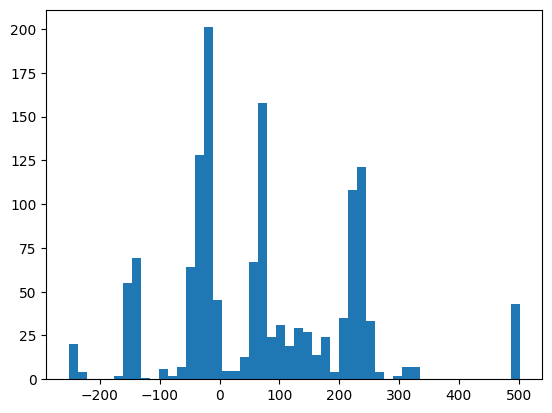

In [34]:
plt.hist(Apo_w_RV_p_ERR["radial_velocity"], bins = 50)

In [35]:
print(np.mean(Apo_NGC3201['FE_H']))
print(np.std(Apo_NGC3201['FE_H']))
print("")
print(np.mean(NGC3201['FeH']))
print(np.std(NGC3201['FeH']))

-1.3449159
0.058000024

-1.3955204788140894
0.1485495604792906


In [36]:
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, np.sqrt(variance))

In [37]:
weighted_avg_and_std(Apo_NGC3201['FE_H'], weights = Apo_NGC3201['FE_H_ERR'])

(np.float32(-1.3450923), np.float32(0.057403907))

In [38]:
weighted_avg_and_std(NGC3201['FeH'], weights=NGC3201['e_FeH'] )

(np.float64(-1.4057344179389786), np.float64(0.14964347678352172))

In [39]:
print(chem_list)

['FeH', 'CaFe', 'SiFe', 'TiFe', 'NiFe', 'ZrFe', 'CeFe', 'NdFe']


In [40]:
element_list_full = ["H", "Fe", "Ca", "Si", "Ti", "Ni", "Zr", "Ce", "Nd"]
element_list_partial_large = [ "Ca", 'Si', "Ti", 'Ni', "Zr", "Ce", "Nd"] #does not contain H, Fe, Si, or Ni
element_list_partial_small = [ "Ca", "Ti", "Zr", "Ce", "Nd"]  #does not contain H, Fe, Si, or Ni
element_list_partial_pradosh = [ "FeH", "CaFe", "TiFe", "ZrFe", "CeFe", "NdFe"] #does not contain H, Si, or Ni
Pradosh_Apogee_elements = ['Ca', 'Ti', 'Ce'] #this is to compare with Apogee

Full_Apogee_chem_list = ['C', 'CI', 'N', 'O', 'NA', 'MG', 'AL', 'SI', 'P', 'S', 'K', 'CA', 'TI', 'TIII', 'V', 'CR', 'MN', 'CO', 'NI', 'CU', 'CE', 'YB']
Apogee_Pradosh_elements = ["CA", "TI", "CE"] #this is to compare with Pradosh
Apogee_elemts_1 = ['CA', 'TI', 'N','AL', 'C']

picked_element_list = {'element_list_full': element_list_full, 
                       'element_list_partial_large': element_list_partial_large, 
                       'element_list_partial_small':element_list_partial_small, 
                       'element_list_partial_pradosh':element_list_partial_pradosh,
                       'Pradosh_Apogee_elements': Pradosh_Apogee_elements,
                       'Apogee_Pradosh_elements': Apogee_Pradosh_elements,
                       'Full_Apogee_chem_list': Full_Apogee_chem_list,
                       'Apogee_elemts_1': Apogee_elemts_1,
                       }

# picked_element_list['element_list_full']
# picked_element_list['element_list_full'][1]
# print(picked_element_list.keys())
# print(picked_element_list.values())
# print(len(picked_element_list["element_list_full"]))


def make_elm_ratio_combinations_pradosh( data_set, element_list):
    element_in_list = picked_element_list[element_list]
    new_element_ratios_list = []
    new_element_ratio_errors_list = []

    for i in range(len(element_in_list)):
        for j in range(i+1, len(element_in_list)):
            if j in ["Fe", "H"]:
                print("nemorator is Fe or H")
            elif i not in ["Fe", "H"]:
                pradosh_col_name_for_numerator = element_in_list[j] + "Fe" # finds the names of the columns that will be needed to to calculate the numerator in the new ratio. E.g. if I want Ca/Ti, this would get Ca/Fe for the numerator 
                # print("pradosh_col_name_for_numerator:", pradosh_col_name_for_numerator)
                pradosh_err_col_numerator = 'e_' + pradosh_col_name_for_numerator # same as above but now adds the 'e_' to find the error column for the corresponding ratio column
                # print('pradosh_err_col_numerator:', pradosh_err_col_numerator)
            if i in ["Fe", "H"]:
                print("denominator is Fe or H")
            elif i not in ["Fe", "H"]:
                pradosh_col_name_for_denominator = element_in_list[i] + "Fe" # finds the names of the columns that will be needed to to calculate the denominator in the new ratio. E.g. if I want Ca/Ti, this would get Ti/Fe for the denominator 
                # print('pradosh_col_name_for_denominator:', pradosh_col_name_for_denominator)
                pradosh_err_col_denominator = 'e_' + pradosh_col_name_for_denominator # same as above but now adds the 'e_' to find the error column for the corresponding ratio column
                # print('pradosh_err_col_denominator:', pradosh_err_col_denominator)
            
            new_ratio_label = element_in_list[j] + element_in_list[i]
            # print('new_ratio_label:', new_ratio_label)
            new_element_ratios_list.append(new_ratio_label)
            # print("new_element_ratios_list", new_element_ratios_list)
            # print("")

            new_ratio_error_label = 'e_' + element_in_list[j] + element_in_list[i]
            # print(new_ratio_error_label)
            new_element_ratio_errors_list.append(new_ratio_error_label)
            # print("new_element_ratio_errors_list", new_element_ratio_errors_list)
            # print("")

            data_set[new_ratio_label] = data_set[pradosh_col_name_for_numerator] - data_set[pradosh_col_name_for_denominator] # this adds a new column to pradosh's catalog. It give the column the name and finds the ratio values
            data_set[new_ratio_error_label] = np.sqrt((data_set[pradosh_err_col_numerator])**2 + (data_set[pradosh_err_col_denominator])**2)

    return data_set, new_element_ratios_list, new_element_ratio_errors_list,

def make_elm_ratio_combinations_Apogee( data_set, element_list):
    element_in_list = picked_element_list[element_list]
    new_element_ratios_list = []
    new_element_ratio_errors_list = []

    for i in range(len(element_in_list)):
        for j in range(i+1, len(element_in_list)):
            if j in ["FE", "H"]:
                print("nemorator is FE or H")
            elif i not in ["Fe", "H"]:
                Apogee_col_name_for_numerator = element_in_list[j] + "_FE" # finds the names of the columns that will be needed to to calculate the numerator in the new ratio. E.g. if I want Ca/Ti, this would get Ca/Fe for the numerator 
                # print("Apogee_col_name_for_numerator:", Apogee_col_name_for_numerator)
                Apogee_err_col_numerator = Apogee_col_name_for_numerator + '_ERR' # same as above but now adds the 'e_' to find the error column for the corresponding ratio column
                # print('Apogee_err_col_numerator:', Apogee_err_col_numerator)
            if i in ["Fe", "H"]:
                print("denominator is FE or H")
            elif i not in ["FE", "H"]:
                Apogee_col_name_for_denominator = element_in_list[i] + "_FE" # finds the names of the columns that will be needed to to calculate the denominator in the new ratio. E.g. if I want Ca/Ti, this would get Ti/Fe for the denominator 
                # print('Apogee_col_name_for_denominator:', Apogee_col_name_for_denominator)
                Apogee_err_col_denominator = Apogee_col_name_for_denominator  + '_ERR' # same as above but now adds the 'e_' to find the error column for the corresponding ratio column
                # print('Apogee_err_col_denominator:', Apogee_err_col_denominator)
            
            new_ratio_label = element_in_list[j] + '_' + element_in_list[i]
            # print('new_ratio_label:', new_ratio_label)
            new_element_ratios_list.append(new_ratio_label)
            # print("new_element_ratios_list", new_element_ratios_list)
            # print("")

            new_ratio_error_label = element_in_list[j] + '_' + element_in_list[i] + '_ERR'
            # print(new_ratio_error_label)
            new_element_ratio_errors_list.append(new_ratio_error_label)
            # print("new_element_ratio_errors_list", new_element_ratio_errors_list)
            # print("")

            data_set[new_ratio_label] = data_set[Apogee_col_name_for_numerator] - data_set[Apogee_col_name_for_denominator] # this adds a new column to pradosh's catalog. It give the column the name and finds the ratio values
            data_set[new_ratio_error_label] = np.sqrt((data_set[Apogee_err_col_numerator])**2 + (data_set[Apogee_err_col_denominator])**2)
            data_set = data_set.dropna(subset=[new_ratio_label])

    return data_set, new_element_ratios_list, new_element_ratio_errors_list,

In [41]:
# Apogee_element_list_I_chose = 'Apogee_elemts_1'
Apogee_element_list_I_chose = 'Apogee_Pradosh_elements'

Apogee_new_element_ratio_results = make_elm_ratio_combinations_Apogee(Apogee, Apogee_element_list_I_chose)
Apogee_full_catalog_w_new_ratios = Apogee_new_element_ratio_results[0] # this ontains a full catalog from Pradosh but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
Apogee_final_new_element_ratio_list = Apogee_new_element_ratio_results[1]     # this just lists the new columns ratios so I can more easily call them
Apogee_final_new_element_ratio_errors_list = Apogee_new_element_ratio_results[2]    # this just lists the new columns ratio errors so I can more easily call them

Apogee_w_new_ratios_dict = {}
for i in Apogee_full_catalog_w_new_ratios['GC_NAME'].unique():
    key = i
    Apogee_w_new_ratios_dict[key] = Apogee_full_catalog_w_new_ratios[Apogee_full_catalog_w_new_ratios['GC_NAME'] == i]
# print(Apogee_w_new_ratios_dict.keys())

with pd.option_context('display.max_columns', None, 'display.max_rows', None):
    print(Apogee_full_catalog_w_new_ratios.iloc[0])

APOGEE_ID                                                            2M00193767-7210175
GC_NAME                                                                         NGC0104
dPOS                                                                            0.22767
dRV                                                                           -0.804357
dPM                                                                            0.745388
dFeH                                                                           0.010707
RV_Prob                                                                        0.693295
VB_PROB                                                                         0.99996
iFlag                                                                                 0
FILE                                                asStar-dr17-2M00193767-7210175.fits
TARGET_ID                                               lco25m.47TUC.2M00193767-7210175
APSTAR_ID                       

In [42]:
# element_list_I_chose = 'element_list_partial_small'
element_list_I_chose = 'Pradosh_Apogee_elements'

Pradosh_new_element_ratio_results_full_catalog = make_elm_ratio_combinations_pradosh(flagged, element_list_I_chose)
Pradosh_full_catalog_w_new_ratios = Pradosh_new_element_ratio_results_full_catalog[0] # this ontains a full catalog from Pradosh but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
final_new_element_ratio_list = Pradosh_new_element_ratio_results_full_catalog[1]     # this just lists the new columns ratios so I can more easily call them
final_new_element_ratio_errors_list = Pradosh_new_element_ratio_results_full_catalog[2]    # this just lists the new columns ratio errors so I can more easily call them

new_element_ratio_results_NGC3201 = make_elm_ratio_combinations_pradosh(NGC3201, element_list_I_chose)
Pradosh_NGC3201_w_new_ratios = new_element_ratio_results_NGC3201[0] # this ontains a full catalog from Pradosh but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                    # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small

new_element_ratio_results_NGC0104 = make_elm_ratio_combinations_pradosh(NGC0104_matched, element_list_I_chose)
Apo_p_Pradosh_new_ratios_NGC0104 = new_element_ratio_results_NGC0104[0]

new_element_ratio_results_NGC5139 = make_elm_ratio_combinations_pradosh(NGC5139_matched, element_list_I_chose)
Apo_p_Pradosh_new_ratios_NGC5139 = new_element_ratio_results_NGC5139[0]

new_element_ratio_results_NGC6121 = make_elm_ratio_combinations_pradosh(NGC6121_matched, element_list_I_chose)
Apo_p_Pradosh_new_ratios_NGC6121 = new_element_ratio_results_NGC6121[0]

new_element_ratio_results_NGC6254 = make_elm_ratio_combinations_pradosh(NGC6254_matched, element_list_I_chose)
Apo_p_Pradosh_new_ratios_NGC6254 = new_element_ratio_results_NGC6254[0]

new_element_ratio_results_Closest_E_vs_Lz_to_NGC3201_data = make_elm_ratio_combinations_pradosh(Closest_E_vs_Lz_to_NGC3201_data, element_list_I_chose)
Closest_E_vs_Lz_to_NGC3201_w_new_ratios = new_element_ratio_results_Closest_E_vs_Lz_to_NGC3201_data[0]

new_element_ratio_results_Medium_E_vs_Lz_to_NGC3201_data = make_elm_ratio_combinations_pradosh(Medium_E_vs_Lz_to_NGC3201_data, element_list_I_chose)
Medium_E_vs_Lz_to_NGC3201_w_new_ratios = new_element_ratio_results_Medium_E_vs_Lz_to_NGC3201_data[0]
Medium_E_vs_Lz_to_NGC3201_w_new_ratios
new_element_ratio_results_Large_E_vs_Lz_to_NGC3201_data = make_elm_ratio_combinations_pradosh(Large_E_vs_Lz_to_NGC3201_data, element_list_I_chose)
Large_E_vs_Lz_to_NGC3201_w_new_ratios = new_element_ratio_results_Large_E_vs_Lz_to_NGC3201_data[0]



In [43]:
# for i in chem_list:
#     print("")
#     fig, ax = plt.subplots(2, 4, sharex=False, sharey=False, figsize=(24, 12)) # (rows, colums, share y axis and/or share x axis)
    
#     for j in chem_list:

#         if j in ["FeH","CaFe","TiFe","SiFe"]:
#             row_value = 0 
#         elif j in ['NiFe', 'ZrFe', 'CeFe', 'NdFe']:
#             row_value = 1

#         if j in ['FeH','NiFe']:
#             column_value = 0 
#         elif j in ["CaFe",'ZrFe']:
#             column_value = 1
#         elif j in ["TiFe",'CeFe']:
#             column_value = 2
#         elif j in ["SiFe",'NdFe']:
#             column_value = 3

#         ax[row_value, column_value].scatter(flagged[i], flagged[j], c = flagged["eccentricity"], cmap = "managua_r")
        

#         ax[row_value,column_value].set_xlabel(F"[{i}]")
#         ax[row_value,column_value].set_ylabel(F"[{j}]")
#         ax[row_value,column_value].set_title(F"[{j}] vs [{i}]", fontsize=10)
#         ax[row_value,column_value].legend()
#         print(F"[{i}] and [{j}]")

In [44]:
Halo_cuts_pradosh = Pradosh_full_catalog_w_new_ratios[(Pradosh_full_catalog_w_new_ratios['FeH'] < -0.8) & (Pradosh_full_catalog_w_new_ratios['TiFe'] > 0.25) & (Pradosh_full_catalog_w_new_ratios['Lz'] > -1500) & (Pradosh_full_catalog_w_new_ratios['Lz'] < 1500) & (Pradosh_full_catalog_w_new_ratios['eccentricity'] > 0.5) & (Pradosh_full_catalog_w_new_ratios['eccentricity'] < 0.8)]
# Halo_cuts_pradosh                 

# GSE_cuts_pradosh = 

thickdisk_cuts_pradosh = Pradosh_full_catalog_w_new_ratios[(Pradosh_full_catalog_w_new_ratios['FeH'] < -0.8) & (Pradosh_full_catalog_w_new_ratios['TiFe'] > 0.25) & (Pradosh_full_catalog_w_new_ratios['Lz'] > 0) & (Pradosh_full_catalog_w_new_ratios['eccentricity'] < 0.5)]

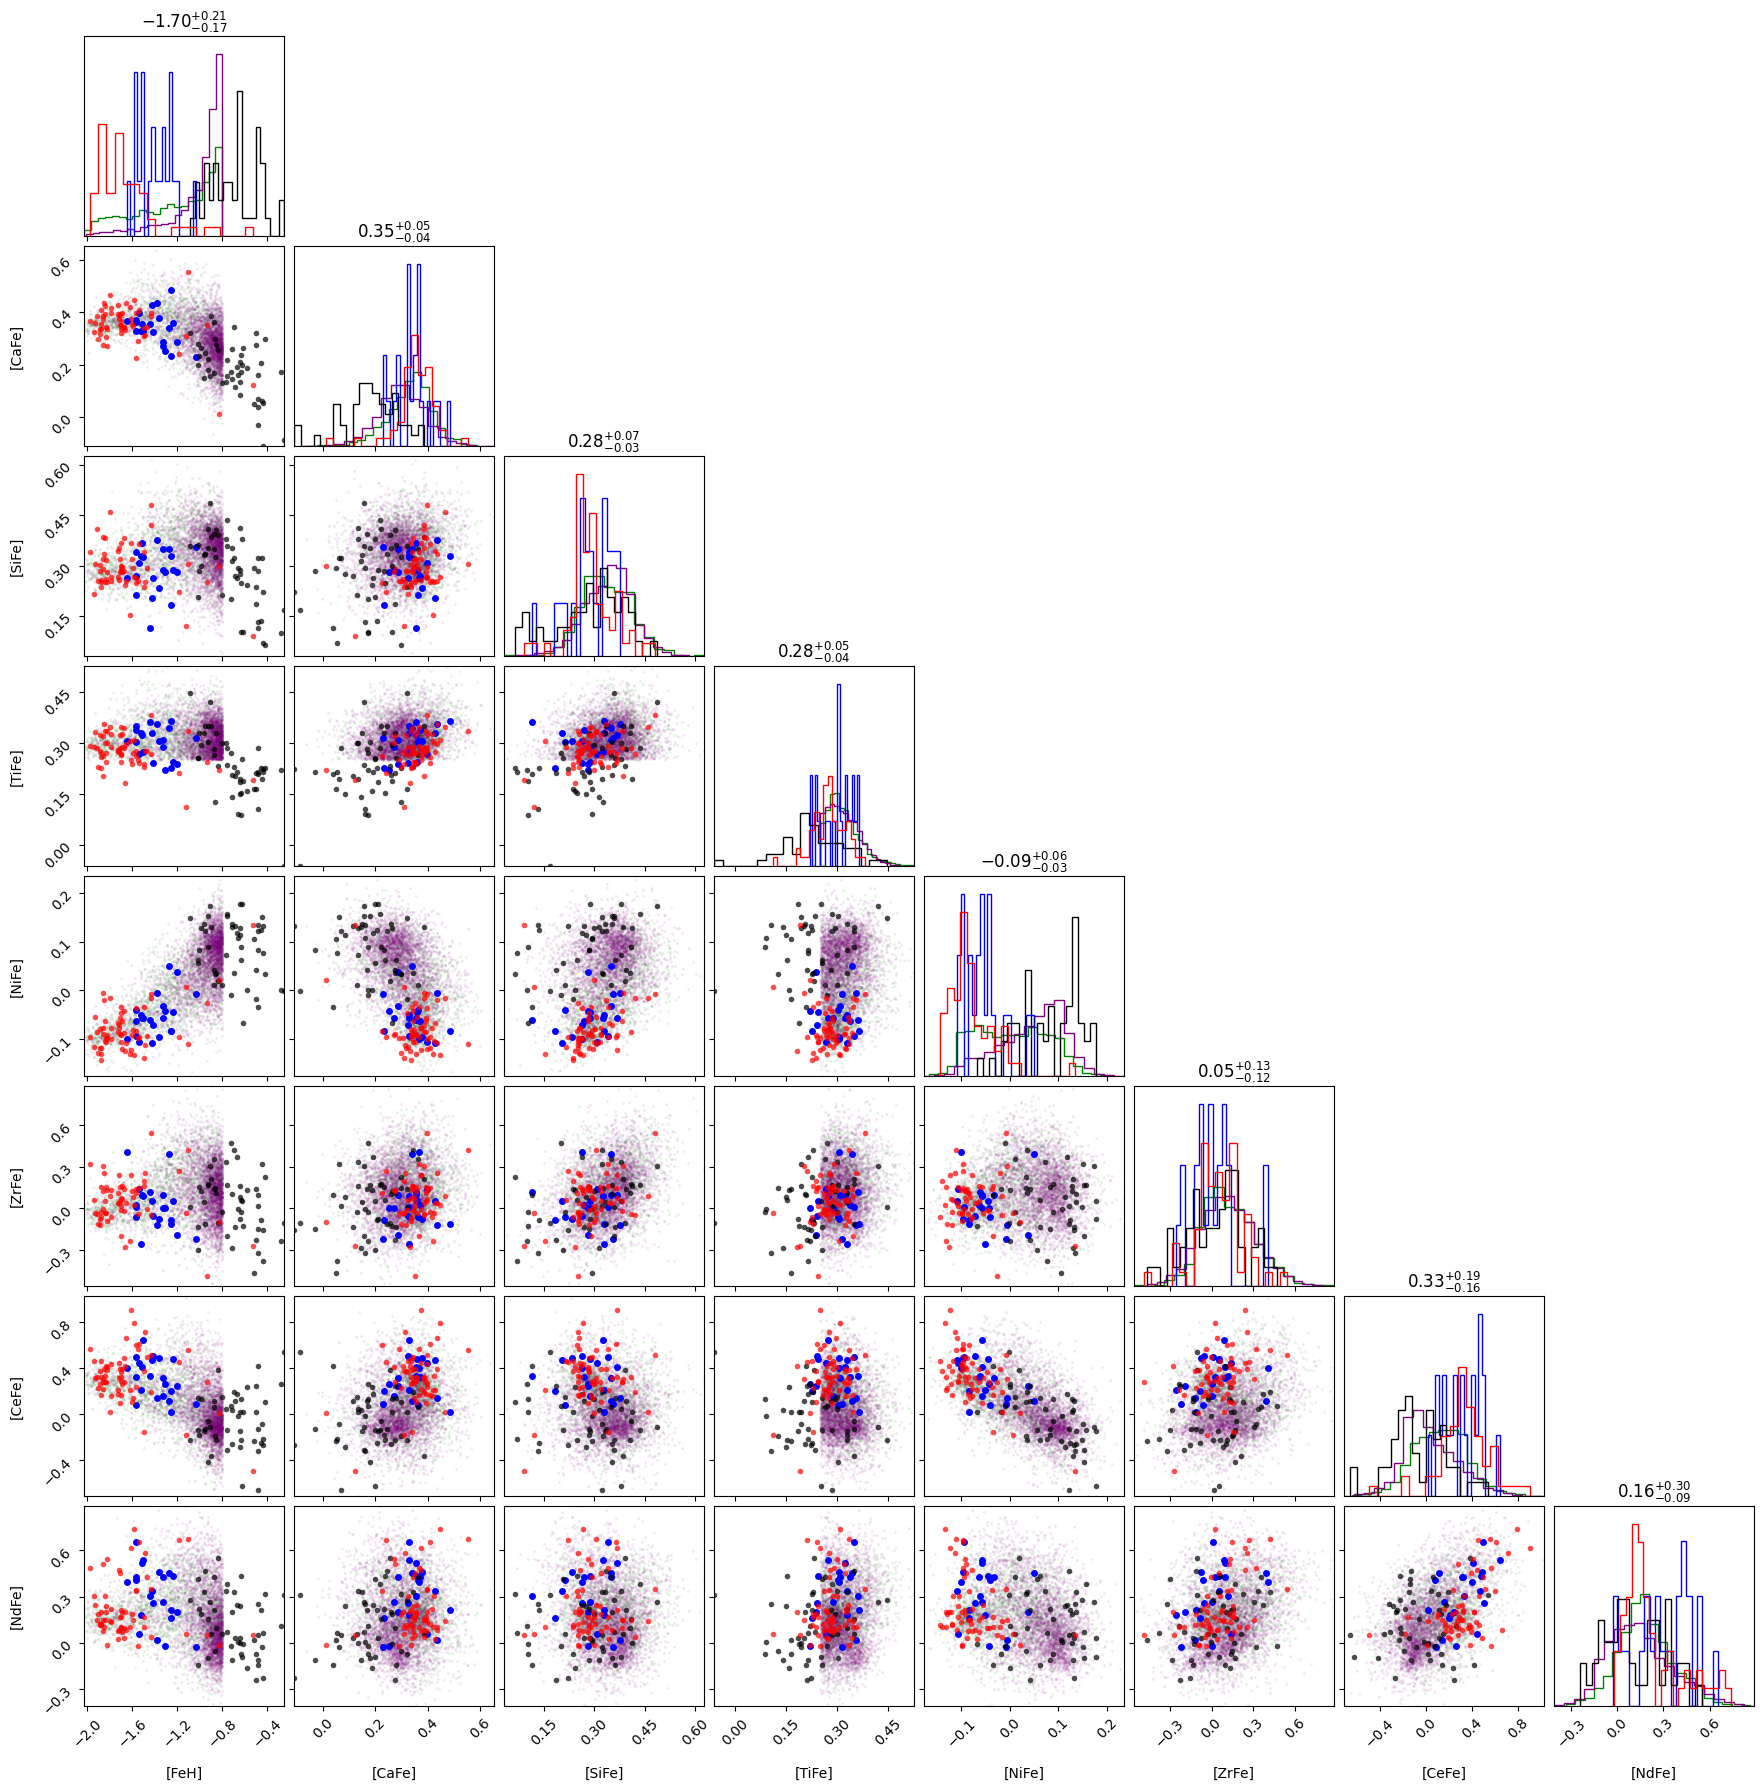

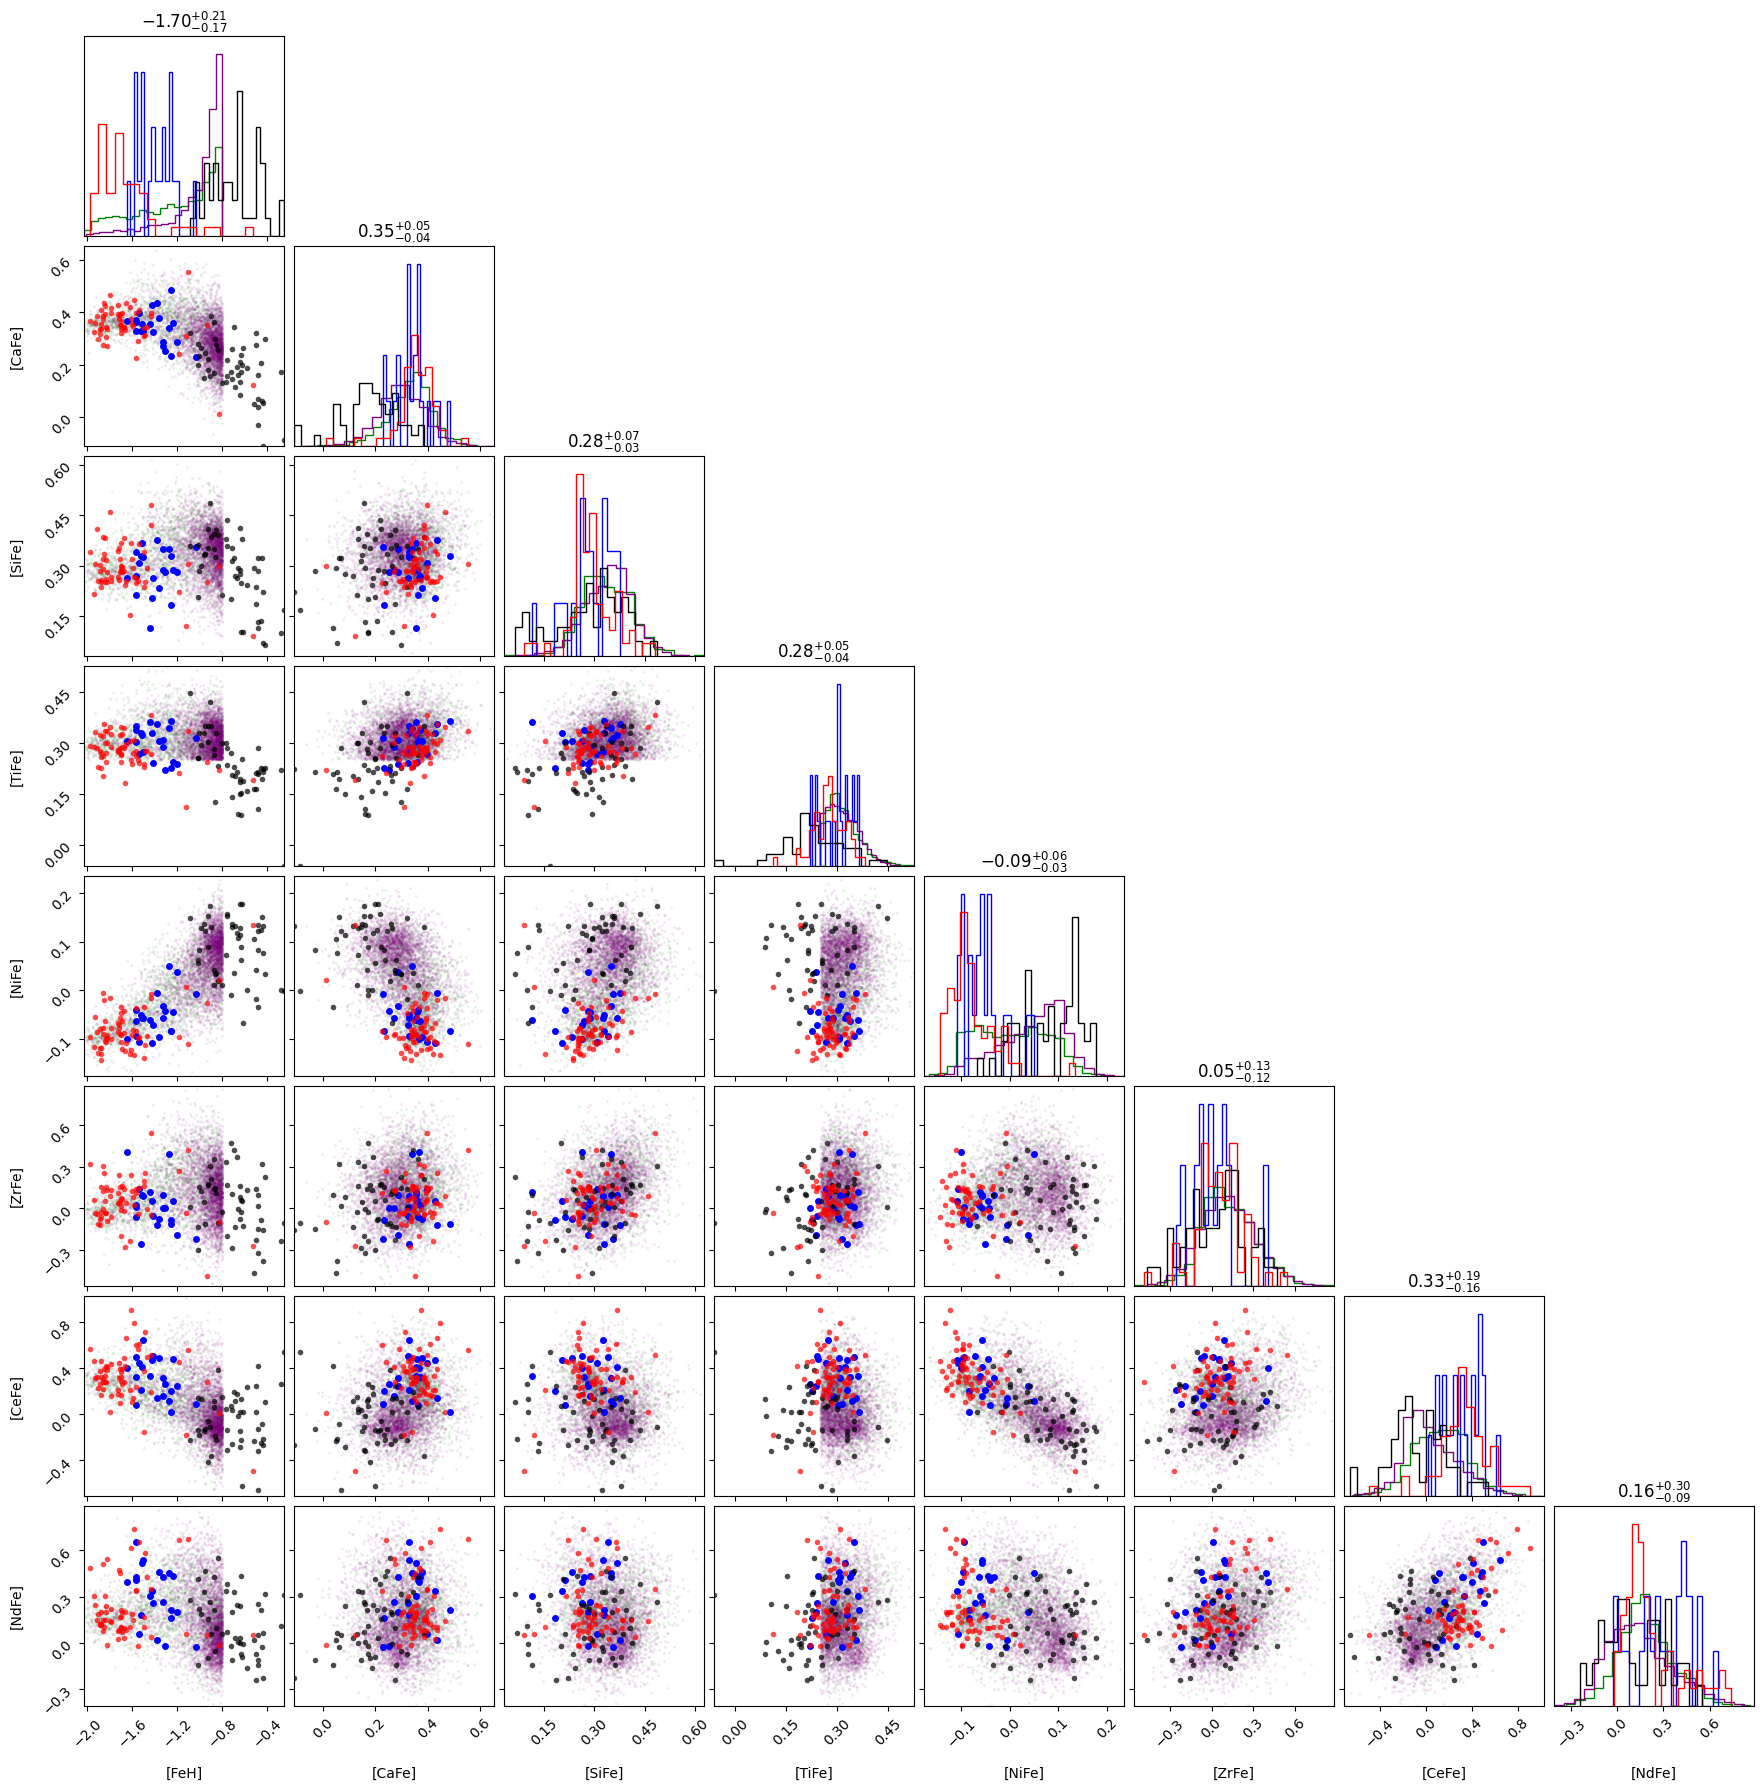

In [45]:
corner_samples_all_pradosh = Pradosh_full_catalog_w_new_ratios[[ i for i in chem_list]] 
corner_samples_NGC3201_pradosh = NGC3201[[i for i in chem_list]]
corner_samples_Halo_pradosh = Halo_cuts_pradosh[[i for i in chem_list]]
corner_samples_Thickdisk_pradosh = thickdisk_cuts_pradosh[[i for i in chem_list]]
corner_samples_NGC0104_matched = NGC0104_matched[[i for i in chem_list]]
corner_samples_NGC5139_matched = NGC5139_matched[[i for i in chem_list]]
labels = [f'[{label}]' for label in chem_list]


figure=corner.corner(
    corner_samples_Halo_pradosh,    
    color="green",
    markersize=5,       
    alpha=0.6,
    hist_kwargs={"density": True, "histtype": "step"},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False, 
    plot_density=False,  
    
    labels=labels,                
    # show_titles=True,
)

corner.corner(
    corner_samples_Thickdisk_pradosh,
    fig=figure,      
    color="purple",
    markersize=5,       
    alpha=0.6,
    hist_kwargs={"density": True, "histtype": "step"},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False, 
    plot_density=False,  
    # show_titles=True,
)


# corner.corner(corner_samples_all_pradosh, labels= labels, 
#                        show_titles=True, title_kwargs={"fontsize": 12},
#                        fig=figure,  
#                        color = "red",
#                        hist_kwargs={ "density": True, "histtype": "step"},
#                        plot_datapoints=True,
#                        plot_contours=False,
#                        fill_contours=False,
#                        plot_density=False,
#                        alpha = 0.5,
#                        markersize = 1
#                         )

corner.corner(
    corner_samples_NGC3201_pradosh,
    fig=figure,      
    color="blue",
    hist_kwargs={"density": True, "histtype": "step"},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False,
    plot_density=False,
    # markersize = 20,
    show_titles=True,
    data_kwargs={'ms': 5, 'alpha': 1, 'color': 'blue'},
)

corner.corner(
    corner_samples_NGC0104_matched,
    fig=figure,      
    color="black",
    hist_kwargs={"density": True, "histtype": "step"},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False,
    plot_density=False,
    # markersize = 20,
    show_titles=True,
    data_kwargs={'ms': 4, 'alpha': 0.7, 'color': 'black'},
)

corner.corner(
    corner_samples_NGC5139_matched,
    fig=figure,      
    color="red",
    hist_kwargs={"density": True, "histtype": "step"},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False,
    plot_density=False,
    # markersize = 20,
    show_titles=True,
    data_kwargs={'ms': 4, 'alpha': 0.7, 'color': 'red'},
)


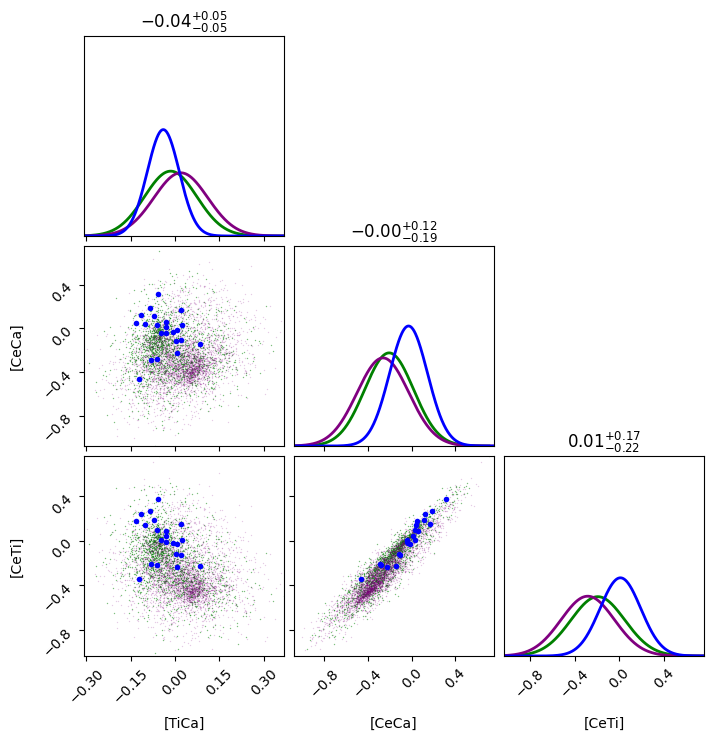

In [46]:
labels = [f'[{label}]' for label in final_new_element_ratio_list]

corner_datasets = {
    "Halo": (Halo_cuts_pradosh, "green", 1, 0.5),
    "Thickdisk": (thickdisk_cuts_pradosh, "purple", 1, 0.2),
    "NGC3201": (Pradosh_NGC3201_w_new_ratios, "blue", 4, 1.0),
}


# Convert all to values and keep data info
for key in corner_datasets:
    df, color, ms, alpha = corner_datasets[key]
    corner_datasets[key] = (df[final_new_element_ratio_list].values, color, ms, alpha) # might need i for i in final_new_element_ratio_list

# First plot initializes the figure
first_data, first_color, first_ms, first_alpha = corner_datasets["Halo"]
fig = corner.corner(
    first_data,
    labels=labels,
    color=first_color,
    data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
    hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False,
    plot_density=False,
)

ndim = first_data.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

# Function to overlay Gaussian
def overlay_gaussian(data, color):
    for i in range(ndim):
        ax = axes[i, i]
        x = data[:, i]
        x = x[np.isfinite(x)]
        if len(x) > 1:
            mu, sigma = np.mean(x), np.std(x) #this is not weighted properly so I still need to make some changes
            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
            ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

# Overlay remaining datasets
for key, (data, color, ms, alpha) in corner_datasets.items():
    if key != "Halo":
        corner.corner(
            data,
            fig=fig,
            color=color,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(data, color)

NGC3201: 22 stars, 3 element ratios
Apogee_NGC3201: 50 stars, 3 element ratios


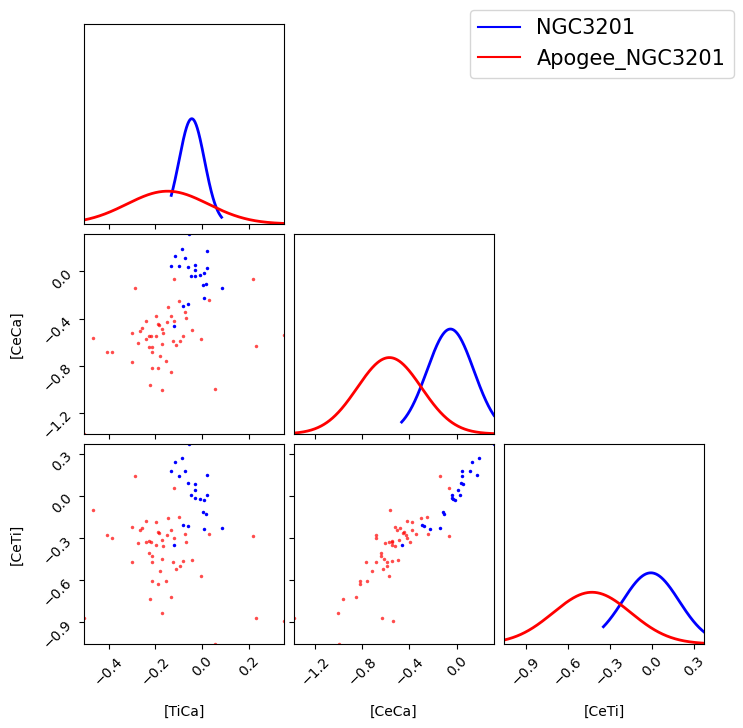

In [47]:
labels = [f'[{label}]' for label in final_new_element_ratio_list]
# labels = [f'[{label}]' for label in Apogee_final_new_element_ratio_list]

first_plot = 'NGC3201' #pick one of the keys in corner_datasets

corner_datasets = {
    # "Halo": (Halo_cuts_pradosh[final_new_element_ratio_list], Halo_cuts_pradosh[final_new_element_ratio_errors_list], "green", 1, 0.5),
    # "Thickdisk": (thickdisk_cuts_pradosh[final_new_element_ratio_list], thickdisk_cuts_pradosh[final_new_element_ratio_errors_list], "purple", 1, 0.2),
    "NGC3201": (Pradosh_NGC3201_w_new_ratios[final_new_element_ratio_list], Pradosh_NGC3201_w_new_ratios[final_new_element_ratio_errors_list],"blue", 2.5, 1.0),
    # "NGC0104":(Apo_p_Pradosh_new_ratios_NGC0104[final_new_element_ratio_list], Apo_p_Pradosh_new_ratios_NGC0104[final_new_element_ratio_errors_list],"black", 2.5, 0.7),
    # "NGC5139":(Apo_p_Pradosh_new_ratios_NGC5139[final_new_element_ratio_list], Apo_p_Pradosh_new_ratios_NGC5139[final_new_element_ratio_errors_list],"red", 2.5, 0.7),
    # "NGC6121":(Apo_p_Pradosh_new_ratios_NGC6121[final_new_element_ratio_list], Apo_p_Pradosh_new_ratios_NGC6121[final_new_element_ratio_errors_list],"orange", 2.5, 0.7),
    # "NGC6254":(Apo_p_Pradosh_new_ratios_NGC6254[final_new_element_ratio_list], Apo_p_Pradosh_new_ratios_NGC6254[final_new_element_ratio_errors_list],"teal", 2.5, 0.7),
    # "Closest_E_vs_Lz_to_NGC3201":(Closest_E_vs_Lz_to_NGC3201_w_new_ratios[final_new_element_ratio_list], Closest_E_vs_Lz_to_NGC3201_w_new_ratios[final_new_element_ratio_errors_list],"teal", 2.5, 0.7),
    # "Medium_E_vs_Lz_to_NGC3201":(Medium_E_vs_Lz_to_NGC3201_w_new_ratios[final_new_element_ratio_list], Medium_E_vs_Lz_to_NGC3201_w_new_ratios[final_new_element_ratio_errors_list],"red", 2.5, 0.7),
    # "Large_E_vs_Lz_to_NGC3201":(Large_E_vs_Lz_to_NGC3201_w_new_ratios[final_new_element_ratio_list], Large_E_vs_Lz_to_NGC3201_w_new_ratios[final_new_element_ratio_errors_list],"black", 2.5, 0.7),
    # "Apogee_full_catalog_w_new_ratios":(Apogee_full_catalog_w_new_ratios[Apogee_final_new_element_ratio_list], Apogee_full_catalog_w_new_ratios[Apogee_final_new_element_ratio_errors_list],"green", 2.5, 0.7),
    "Apogee_NGC3201":(Apogee_w_new_ratios_dict['NGC3201'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC3201'][Apogee_final_new_element_ratio_errors_list],"red", 2.5, 0.7),
    # "Apogee_NGC5139":(Apogee_w_new_ratios_dict['NGC5139'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC5139'][Apogee_final_new_element_ratio_errors_list],"blue", 2.5, 0.2),
    # "ApogeeC_Ter9":(Apogee_w_new_ratios_dict['Ter9'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['Ter9'][Apogee_final_new_element_ratio_errors_list],"black", 2.5, 1),
    # "Apogee_NGC1851":(Apogee_w_new_ratios_dict['NGC1851'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC1851'][Apogee_final_new_element_ratio_errors_list],"orange", 2.5, 0.8),
    # "Apogee_NGC6752":(Apogee_w_new_ratios_dict['NGC6752'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC6752'][Apogee_final_new_element_ratio_errors_list],"red", 2.5, 0.4),
    # "Apogee_NG6809":(Apogee_w_new_ratios_dict['NGC6809'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC6809'][Apogee_final_new_element_ratio_errors_list],"green", 2.5, 0.7),
    # "Apogee_NGC0288":(Apogee_w_new_ratios_dict['NGC0288'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC0288'][Apogee_final_new_element_ratio_errors_list],"red", 2.5, 0.7),
    #  "Apogee_NGC6101":(Apogee_w_new_ratios_dict['NGC6101'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC6101'][Apogee_final_new_element_ratio_errors_list],"red", 2.5, 0.7),
    # "Apogee_NG6388":(Apogee_w_new_ratios_dict['NGC6388'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC6388'][Apogee_final_new_element_ratio_errors_list],"green", 2.5, 0.7),
    # "Apogee_NG0104":(Apogee_w_new_ratios_dict['NGC0104'][Apogee_final_new_element_ratio_list],Apogee_w_new_ratios_dict['NGC0104'][Apogee_final_new_element_ratio_errors_list],"orange", 2.5, 0.7),



}

# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)
 
first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]
fig = corner.corner(
first_values,
labels=labels,
color=first_color,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
plot_datapoints=True,
plot_contours=False,
fill_contours=False,
plot_density=False,
)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

# Function to overlay Gaussian
def overlay_gaussian(values, errors, color):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:,i]
        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]
        sigma_x = sigma_x[mask]
        if len(x) > 1:
            mu, sigma = weighted_avg_and_std(x, sigma_x) #now this should be weighting the errors better
            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
            ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color)
    handles.append(plt.Line2D([0], [0], color = color, label = key))


fig.legend(handles=handles, 
           loc="upper right", 
           bbox_to_anchor=(1.0, 0.98),
        #    ncol=len(handles),
        #    frameon=False,
           fontsize=15) 


In [48]:
"""I wasn't able to run Closest_E_vs_Lz_to_NGC3201 in the cell above. This was becasue for some reason the corner plots
will use the line of code below to make sure that the sample size is larger than the number of rows I want. In this case i had fewer
stars in the sample than the elemental ratios so it was unahppy.
"""
# print(corner.core.__file__)

#     # assert xs.shape[0] <= xs.shape[1], (
#     #     "I don't believe that you want more " "dimensions than samples!"
#     # )

"I wasn't able to run Closest_E_vs_Lz_to_NGC3201 in the cell above. This was becasue for some reason the corner plots\nwill use the line of code below to make sure that the sample size is larger than the number of rows I want. In this case i had fewer\nstars in the sample than the elemental ratios so it was unahppy.\n"

In [49]:
# Apogee_w_new_ratios_dict_copy = dict(sorted(Apogee_w_new_ratios_dict.items(),key=lambda item: item[1].shape[0], reverse=True)) # this sorts it based on number of rows
Apogee_w_new_ratios_dict_copy = dict(sorted(Apogee_w_new_ratios_dict.items())) #this sorts in alphabetical order
for i in Apogee_w_new_ratios_dict_copy.keys():
    print(i, len(Apogee_w_new_ratios_dict_copy[i]['FE_H']))
# print(Apogee_w_new_ratios_dict.keys())

Djorg_2 7
FSR1758 7
HP1 9
Liller1 1
NGC0104 216
NGC0288 37
NGC0362 36
NGC1851 26
NGC1904 21
NGC2298 1
NGC2808 69
NGC3201 50
NGC5024 1
NGC5139 404
NGC5272 84
NGC5904 91
NGC6093 2
NGC6121 133
NGC6171 15
NGC6205 24
NGC6218 64
NGC6229 2
NGC6254 40
NGC6273 26
NGC6304 18
NGC6316 17
NGC6380 13
NGC6388 34
NGC6397 5
NGC6441 11
NGC6522 3
NGC6528 3
NGC6540 1
NGC6544 19
NGC6553 2
NGC6558 5
NGC6569 4
NGC6642 10
NGC6656 81
NGC6715 230
NGC6717 3
NGC6723 7
NGC6752 94
NGC6809 27
NGC6838 29
NGC7089 19
Pal1 1
Ter10 1
Ter2 3
Ter4 2
Ter5 3
Ter9 5
Ton2 7
UKS1 2


In [50]:
Apogee_w_new_ratios_dict['NGC6752'][Apogee_final_new_element_ratio_list]

,TI_CA,CE_CA,CE_TI
7110,-0.071150,-0.113454,-0.042304
7113,-0.090124,-0.316881,-0.226757
7116,0.049038,-0.215515,-0.264553
7118,-0.292822,-0.176485,0.116337
7119,-0.535392,-0.545065,-0.009673
...,...,...,...
7264,-0.160552,-0.344235,-0.183683
7265,-0.198722,-0.182365,0.016357
7266,-0.208963,-0.161275,0.047688
7270,-0.233505,-0.351165,-0.117660


In [51]:
''' THIS IS FOR 1D THINGS'''

feature_cols = final_new_element_ratio_list
clusters_to_use = {
    "NGC3201": Pradosh_NGC3201_w_new_ratios,
    "Halo": Halo_cuts_pradosh,
    # "Thick_disk": thickdisk_cuts_pradosh,
}

# feature_cols = Apogee_final_new_element_ratio_list
# clusters_to_use = { 
    # "NGC3201": Apogee_w_new_ratios_dict['NGC3201'],
    # "NGC1851": Apogee_w_new_ratios_dict['NGC1851'],
    # "Ter9": Apogee_w_new_ratios_dict['Ter9']
# }

final_output = []
# Combine the clusters into a single DataFrame
df_list = []
for cluster_name, df in clusters_to_use.items():
    df_copy = df.copy()
    df_copy["GC_NAME"] = cluster_name  # label column
    df_list.append(df_copy)

df_all = pd.concat(df_list, ignore_index=True)

# Classification: one feature at a time
for feature in feature_cols:
    # Extract feature column and label
    X = df_all[[feature]].copy()
    y = df_all["GC_NAME"].copy()

    # Remove rows where the feature is NaN
    mask = X[feature].notna()
    X = X[mask]
    y = y[mask]

    # Skip feature if no data is left
    if X.shape[0] == 0:
        print(f"No data available for feature {feature}. Skipping.")
        continue

    # Split into train/test sets
    test_size = 0.2 if X.shape[0] > 10 else 0.1  # adjust test size for very small clusters
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Train Random Forest classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    # Predict and calculate accuracy
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    final_output.append({
        "ratio1": feature,
        "accuracy": acc
        })
final_output = pd.DataFrame(final_output)
final_output = final_output.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

final_output

,ratio1,accuracy
0,TiCa,0.981627
1,CeCa,0.976378
2,CeTi,0.976378


In [52]:
''' THIS IS FOR 2D STUFF'''

# feature_cols = final_new_element_ratio_list
# clusters_to_use = {
#     "NGC3201": Pradosh_NGC3201_w_new_ratios,
#     "Halo": Halo_cuts_pradosh,
#     # "Thick_disk": thickdisk_cuts_pradosh,
#     # 'NGC6254': Apo_p_Pradosh_new_ratios_NGC6254
# }

feature_cols = Apogee_final_new_element_ratio_list
clusters_to_use = { 
    "NGC3201": Apogee_w_new_ratios_dict['NGC3201'],
    # "NGC1851": Apogee_w_new_ratios_dict['NGC1851'],
    "NGC5139": Apogee_w_new_ratios_dict['NGC5139'],
    # "Ter9": Apogee_w_new_ratios_dict['Ter9']
}


# Combine the clusters into a single DataFrame
df_list = []
for Group_Name, df in clusters_to_use.items():
    df_copy = df.copy()
    df_copy["Group_Name"] = Group_Name  # label column
    df_list.append(df_copy)

df_all = pd.concat(df_list, ignore_index=True)
final_output = []
for ratio1 in range(len(feature_cols)):
    for ratio2 in range(ratio1+1,len(feature_cols)):

        col1 = feature_cols[ratio1]
        col2 = feature_cols[ratio2]

        X = df_all[[col1, col2]]#.copy()
        y = df_all["Group_Name"]#.copy()

        # Remove rows where the feature is NaN
        # mask = X[feature_cols[ratio1], feature_cols[ratio2]].notna()
        # X = X[mask]
        # y = y[mask]

        # Split into train/test sets
        test_size = 0.2 if X.shape[0] > 10 else 0.1  # adjust test size for very small clusters
        X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
        )

        # Train Random Forest classifier
        clf = RandomForestClassifier(n_estimators=500, random_state=42)
        clf.fit(X_train, y_train)

        # Predict and calculate accuracy
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        final_output.append({
        "ratio1": col1,
        "ratio2": col2,
        "accuracy": acc
        })
final_output = pd.DataFrame(final_output)
final_output = final_output.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

final_output


,ratio1,ratio2,accuracy
0,TI_CA,CE_TI,0.857143
1,CE_CA,CE_TI,0.846154
2,TI_CA,CE_CA,0.835165


In [53]:
Apogee_w_new_ratios_dict['NGC5139'][Apogee_final_new_element_ratio_list]

,TI_CA,CE_CA,CE_TI
998,-0.182153,0.255865,0.438018
999,-0.366482,-0.257405,0.109077
1025,-0.667542,-0.461735,0.205807
1030,-0.155252,-0.593225,-0.437973
1036,-0.434011,-0.266715,0.167296
...,...,...,...
2743,-0.243906,-0.049905,0.194001
2764,-0.239992,-0.436845,-0.196853
2788,-0.214067,-0.423985,-0.209918
2820,-0.346331,-0.098285,0.248046


In [54]:
#These are the gaia source_ids for the ED-2 stream from Balbinot 2023 https://doi.org/10.1051/0004-6361/202347076
source_ids = [
    759407156314566784,
    779616592350301952,
    1298276602498467072,
    1355410284693698304,
    1473531196822925696,
    1483840527082796160,
    1504043950164231040,
    1505084294322771200,
    1571514072452538752,
    1574800645851240192,
    1577319631286280960,
    1578782394069199488,
    1607956973038473600,
    1613368013356040192,
    1665210536361012480,
    1693676308288915712,
    1698151522476505344,
    1828751586656157952,
    1835597214774359424,
    2110672655835482496,
    3473979147705211776,
    3549718318990080896,
    3592103255289580800,
    3624621311681013504,
    3723617593434390656,
    3757312745743087232,
    3786501309126931328,
    3869876996687740032,
    3915925991063287808,
    3941060277118782208,
    3951060094855048960,
    3963873700285600128,
    3973419660238121728,
    3992080193627189632,
    4008274384997266560,
    4014326268795251712,
    4025946010756238464,
    4154818772254357376,
    4172609385769404032,
    4245522468554091904,
    4479226310758314496,
    4532592619428218624,
    5444820480268295424,
    5991844282681283712,
    6632335060231088896,
    6646097819069706624,
    6746114585056265600,
    6747065215934660608,
]

print(len(source_ids))

ids_str = ",".join(str(i) for i in source_ids)

query = f"""
SELECT 
    source_id, radial_velocity, radial_velocity_error, ra, pmra,pmra_error, dec, pmdec, pmdec_error, parallax, parallax_error 
FROM gaiadr3.gaia_source_lite
WHERE source_id IN ({ids_str})
AND radial_velocity is not NULL
"""

job = Gaia.launch_job(query)
tbl = job.get_results()
ED_2= tbl.to_pandas()
# ED_2 = ensure_native_endian(ED_2)
print(ED_2.head())
print(ED_2.columns)
print(ED_2.shape)

# ED_2.to_csv('ED_2.csv', sep=',', index=False)

48
             source_id  radial_velocity  radial_velocity_error          ra  \
0  5444820480268295424       407.826141               4.795372  160.351501   
1   779616592350301952      -177.463181               1.716529  159.944337   
2  4008274384997266560       -96.095970               5.398828  185.246757   
3  6632335060231088896       346.680298               2.309700  286.530129   
4  6747065215934660608        91.045929               8.016003  299.432109   

        pmra  pmra_error        dec       pmdec  pmdec_error  parallax  \
0  -6.443404    0.018263 -33.317040  -37.082951     0.022640  0.524343   
1 -10.435414    0.016926  40.716551  -58.077957     0.013272  0.523356   
2 -41.881681    0.018426  24.993193 -122.466673     0.016423  1.119235   
3 -27.137542    0.017486 -60.496594  -99.582836     0.017774  1.049501   
4 -28.856642    0.019015 -33.402781 -234.627282     0.013093  1.938336   

   parallax_error  
0        0.021882  
1        0.017122  
2        0.018772  
3  

In [55]:
with pd.option_context('display.max_rows', None):
    print(ED_2["parallax"])

0     0.524343
1     0.523356
2     1.119235
3     1.049501
4     1.938336
5     2.666124
6     0.374083
7     1.183889
8     4.182760
9     0.568347
10    0.928369
11    0.687455
12    0.431872
13    1.769354
14    0.627091
15    1.218878
16    1.882589
17    1.221628
18    1.641537
19    1.545471
20    1.706073
21    2.571698
22    1.966161
23    0.482700
24    0.707151
25    0.982534
26    0.601045
27    1.646499
28    0.897632
29    0.966227
30    2.036041
31    1.981824
32    2.856354
33    0.694252
Name: parallax, dtype: float64


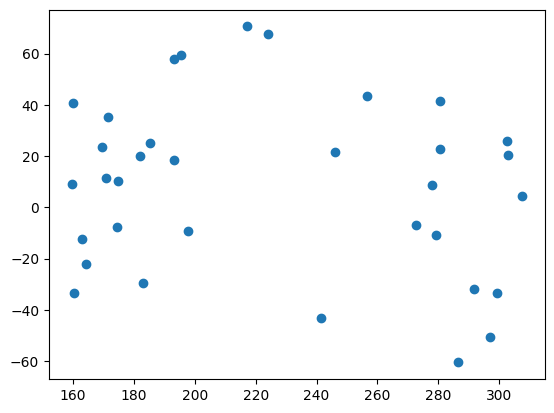

In [56]:
plt.scatter(ED_2['ra'], ED_2['dec'])

In [57]:
len(Halo_cuts_pradosh)

1883

In [58]:
len(thickdisk_cuts_pradosh)

4037

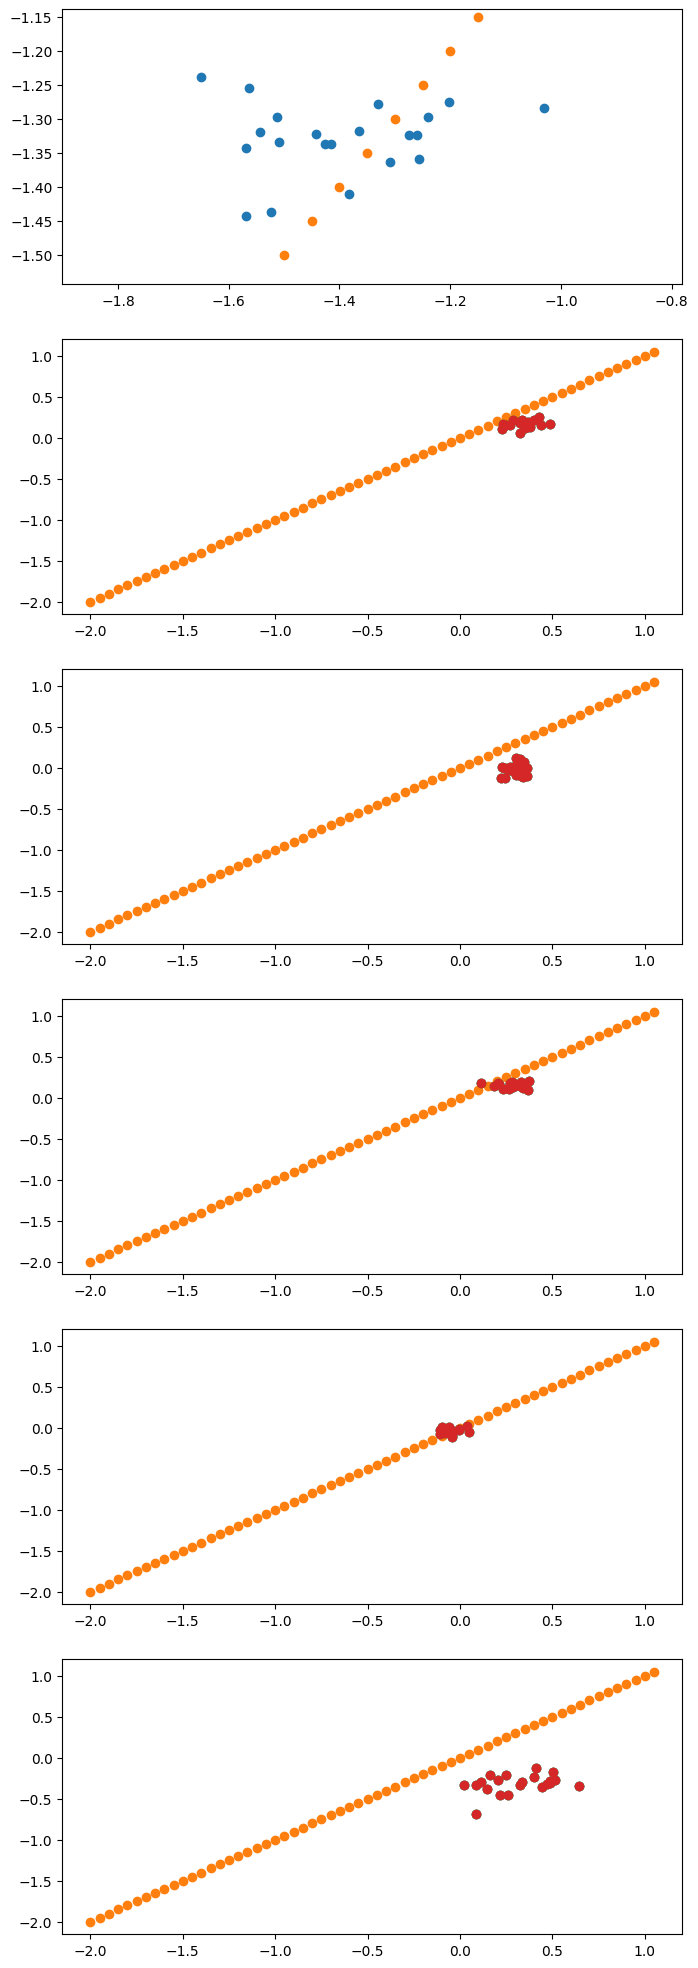

In [59]:
jam = np.arange(-2, 1.1, 0.05)

fig, ax = plt.subplots(6, 1,figsize=(8, 25))

ax[0].scatter(NGC3201_matched['FeH'], NGC3201_matched['FE_H'])
ax[1].scatter(NGC3201_matched['CaFe'], NGC3201_matched['CA_FE'])
ax[2].scatter(NGC3201_matched['TiFe'], NGC3201_matched['TI_FE'])
ax[3].scatter(NGC3201_matched['SiFe'], NGC3201_matched['SI_FE'])
ax[4].scatter(NGC3201_matched['NiFe'], NGC3201_matched['NI_FE'])
ax[5].scatter(NGC3201_matched['CeFe'], NGC3201_matched['CE_FE'])

for i in range(0,6):
    ax[i].scatter(jam,jam)

ax[0].set_xlim(min(NGC3201_matched['FeH']) - 0.25, max(NGC3201_matched['FeH'])+0.25)
ax[1].scatter(NGC3201_matched['CaFe'], NGC3201_matched['CA_FE'])
ax[2].scatter(NGC3201_matched['TiFe'], NGC3201_matched['TI_FE'])
ax[3].scatter(NGC3201_matched['SiFe'], NGC3201_matched['SI_FE'])
ax[4].scatter(NGC3201_matched['NiFe'], NGC3201_matched['NI_FE'])
ax[5].scatter(NGC3201_matched['CeFe'], NGC3201_matched['CE_FE'])

ax[0].set_ylim(min(NGC3201_matched['FE_H'])-0.1, max(NGC3201_matched['FE_H'])+0.1)
ax[1].scatter(NGC3201_matched['CaFe'], NGC3201_matched['CA_FE'])
ax[2].scatter(NGC3201_matched['TiFe'], NGC3201_matched['TI_FE'])
ax[3].scatter(NGC3201_matched['SiFe'], NGC3201_matched['SI_FE'])
ax[4].scatter(NGC3201_matched['NiFe'], NGC3201_matched['NI_FE'])
ax[5].scatter(NGC3201_matched['CeFe'], NGC3201_matched['CE_FE'])


FeH
/tmp/ipykernel_2918/4211435.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,3].legend()

CaFe
SiFe
TiFe
NiFe
ZrFe
CeFe
NdFe


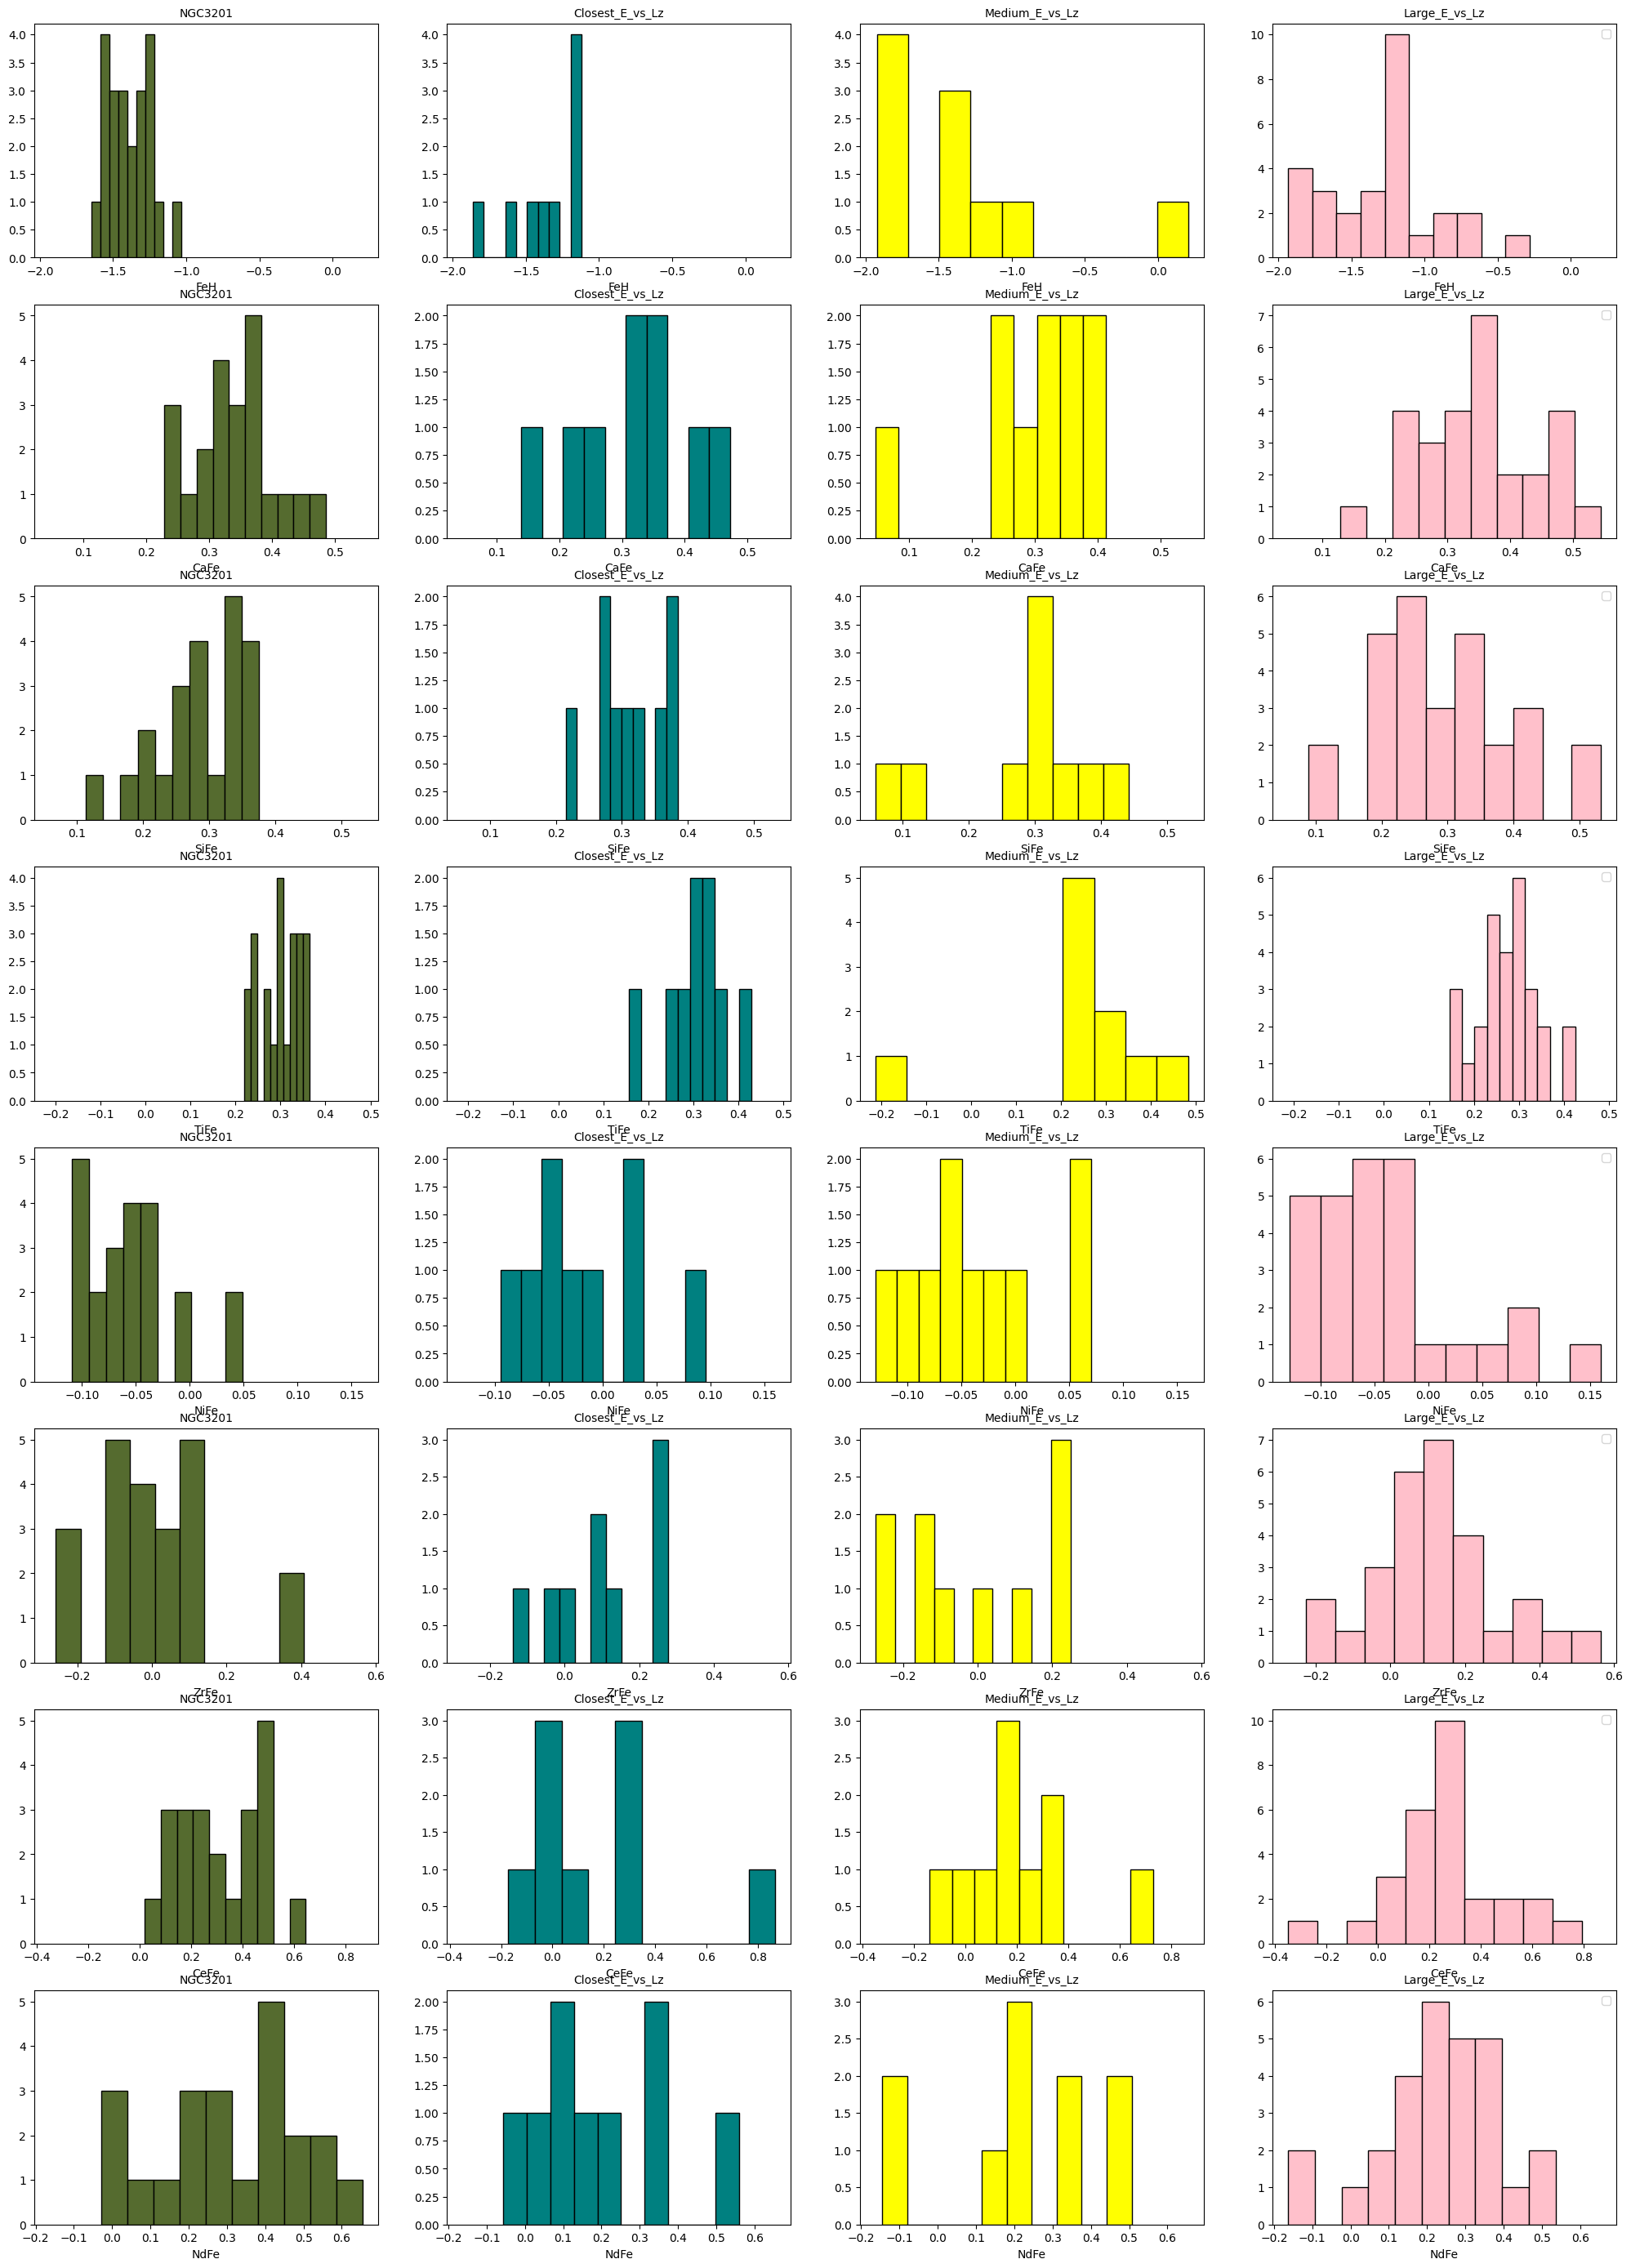

In [60]:
fig, ax = plt.subplots(8, 4, sharex='row', sharey=False, figsize=(25, 35))
for i in range(len(chem_list)):
    print(chem_list[i])
    ax[i,0].hist(NGC3201[F'{chem_list[i]}'], edgecolor = "black", density = False, color = "darkolivegreen")
    ax[i,1].hist(Closest_E_vs_Lz_to_NGC3201_data[F'{chem_list[i]}'], edgecolor = "black", density = False, color = "teal")
    ax[i,2].hist(Medium_E_vs_Lz_to_NGC3201_data[F'{chem_list[i]}'], edgecolor = "black", density = False, color = "yellow")
    ax[i,3].hist(Large_E_vs_Lz_to_NGC3201_data[F'{chem_list[i]}'], edgecolor = "black", density = False, color = "pink")

    ax[i,0].set_xlabel(F'{chem_list[i]}')
    ax[i,1].set_xlabel(F'{chem_list[i]}')
    ax[i,2].set_xlabel(F'{chem_list[i]}')
    ax[i,3].set_xlabel(F'{chem_list[i]}')
    ax[i,0].set_title('NGC3201', fontsize=10)
    ax[i,1].set_title('Closest_E_vs_Lz', fontsize=10)
    ax[i,2].set_title('Medium_E_vs_Lz', fontsize=10)
    ax[i,3].set_title('Large_E_vs_Lz', fontsize=10)
    ax[i,3].legend()

['FeH', 'CaFe', 'SiFe', 'TiFe', 'NiFe', 'ZrFe', 'CeFe', 'NdFe']
NGC3201: 22 stars, 8 element ratios
Closest_E_vs_Lz_to_NGC3201: 9 stars, 8 element ratios
Medium_E_vs_Lz_to_NGC3201: 10 stars, 8 element ratios
Large_E_vs_Lz_to_NGC3201: 28 stars, 8 element ratios
mu:  -1.4057344179389786     sigma:  0.14964347678352172
mu:  0.3451380742717063     sigma:  0.07102362514366951
mu:  0.29132025082610424     sigma:  0.0668358505545349
mu:  0.2995341784449455     sigma:  0.04731860270695299
mu:  -0.05833830564269075     sigma:  0.04271934762170076
mu:  -0.004247553554106913     sigma:  0.16401623854805797
mu:  0.2955440653376496     sigma:  0.18330399689071644
mu:  0.2832650872566149     sigma:  0.20795854765617813
mu:  -1.3229088562145976     sigma:  0.21647203596247433
mu:  0.2833592525065715     sigma:  0.11484962761735484
mu:  0.31249784276511305     sigma:  0.05341665717536885
mu:  0.3258591333535043     sigma:  0.07431960098120703
mu:  -0.003112714346822323     sigma:  0.061533124425733804

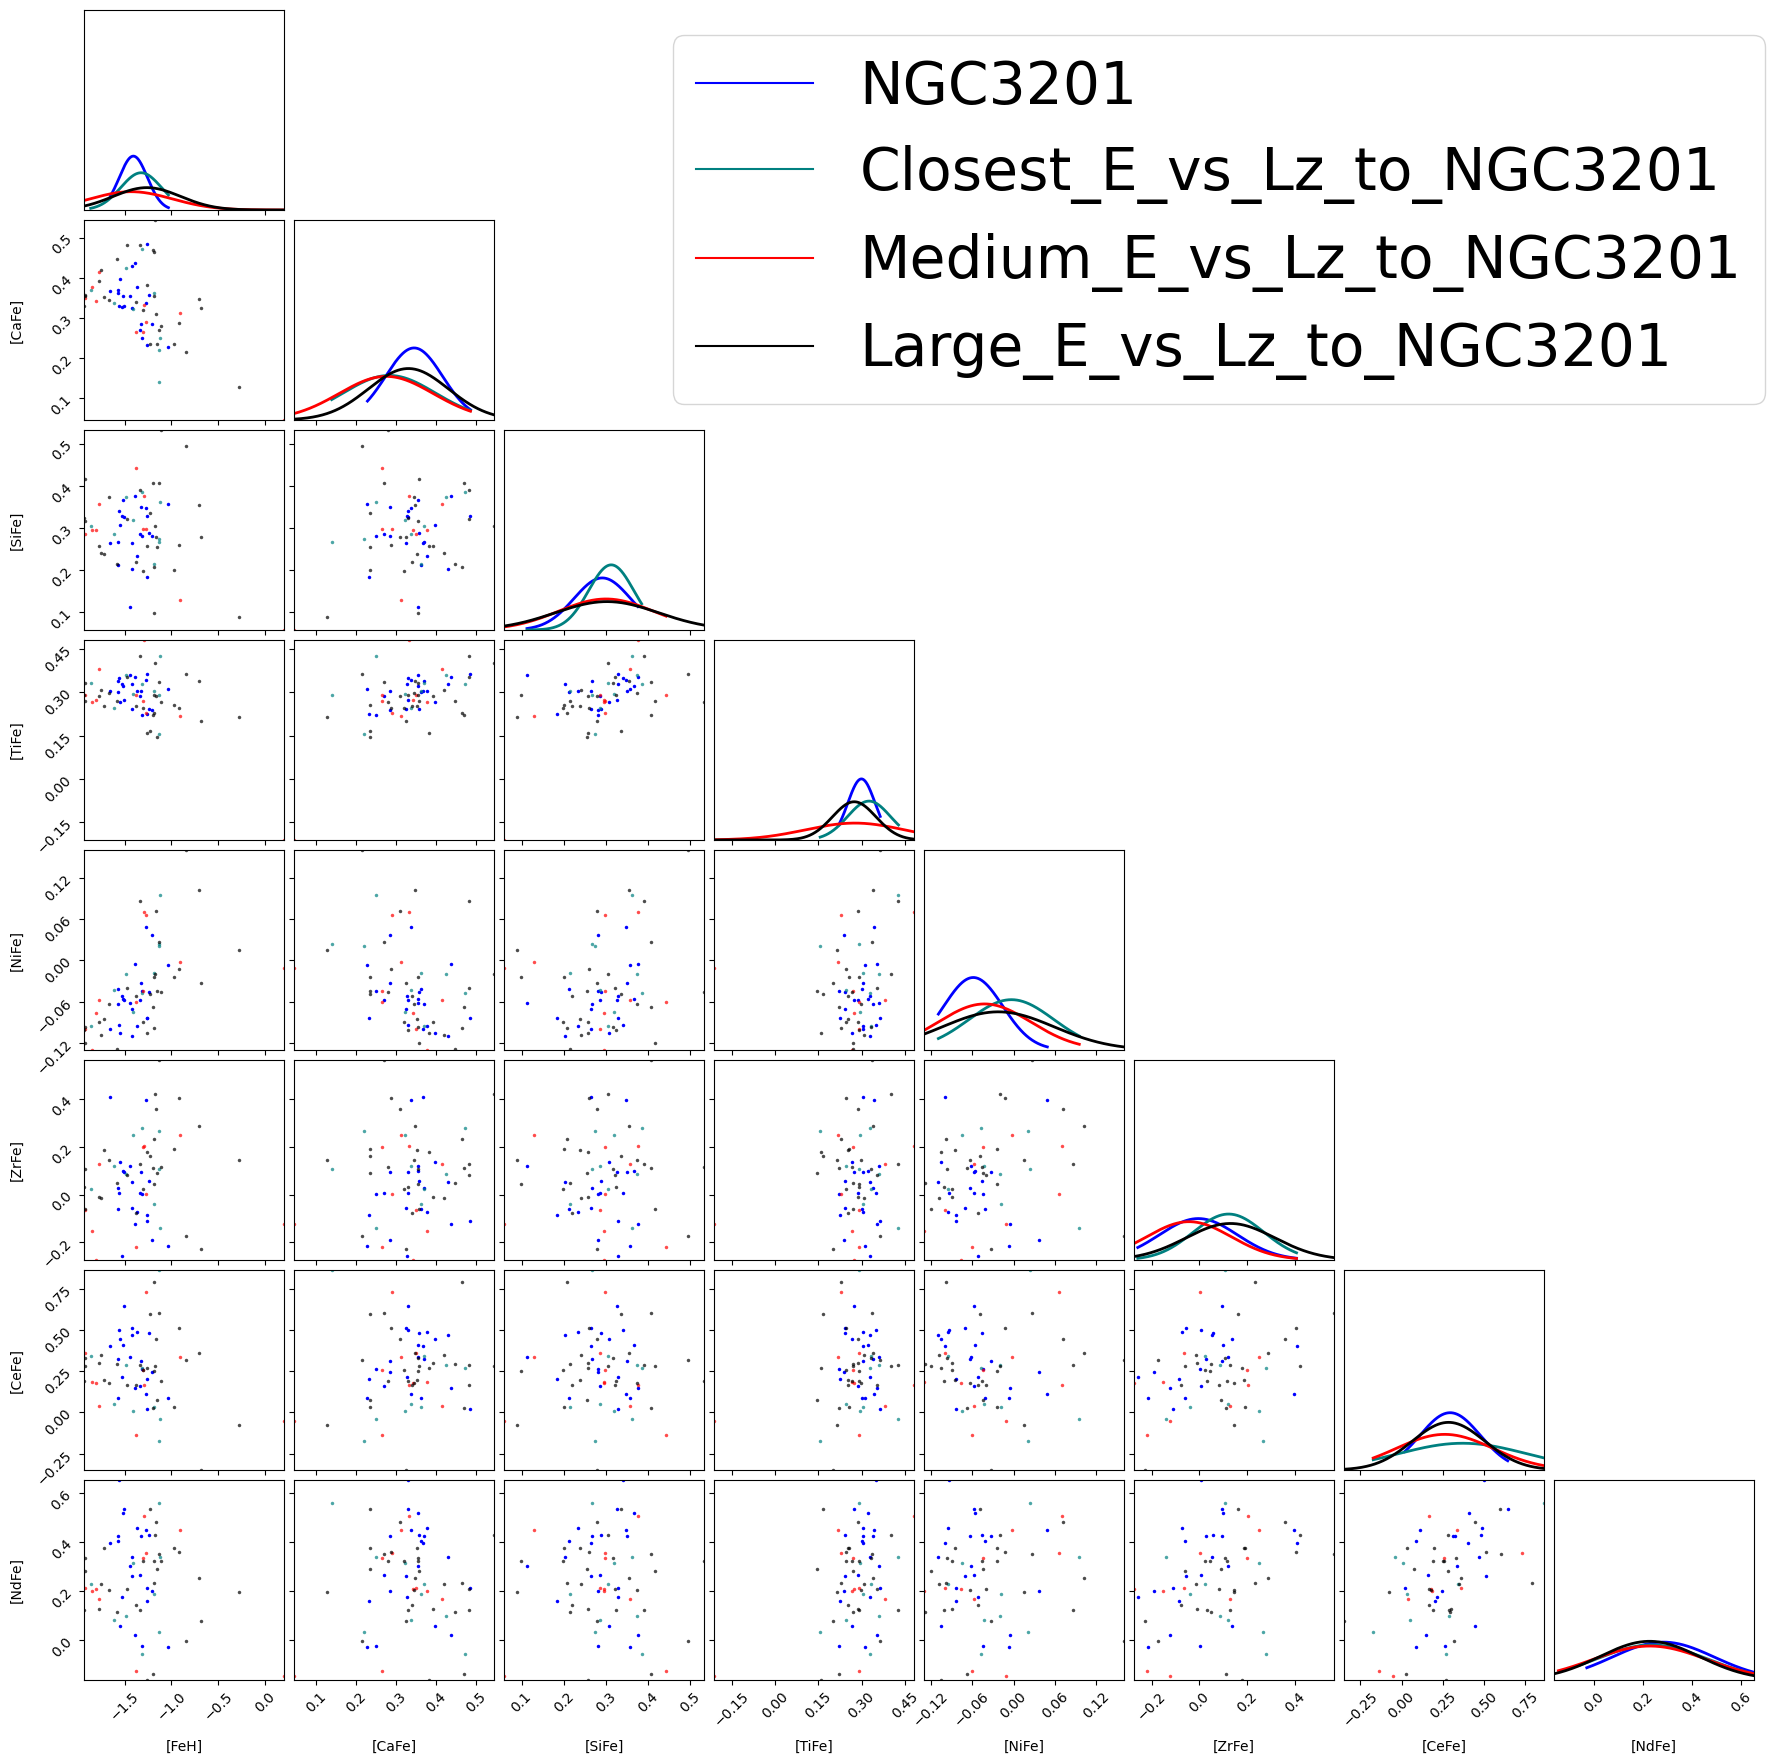

In [62]:
labels = [f'[{label}]' for label in chem_list]
print(chem_list)
first_plot = 'NGC3201' #pick one of the keys in corner_datasets

corner_datasets = {
    
    "NGC3201": (NGC3201[chem_list], NGC3201[chem_list_errors],"blue", 2.5, 1.0),
    "Closest_E_vs_Lz_to_NGC3201":(Closest_E_vs_Lz_to_NGC3201_data[chem_list], Closest_E_vs_Lz_to_NGC3201_data[chem_list_errors],"teal", 2.5, 0.7),
    "Medium_E_vs_Lz_to_NGC3201":(Medium_E_vs_Lz_to_NGC3201_data[chem_list], Medium_E_vs_Lz_to_NGC3201_data[chem_list_errors],"red", 2.5, 0.7),
    "Large_E_vs_Lz_to_NGC3201":(Large_E_vs_Lz_to_NGC3201_data[chem_list], Large_E_vs_Lz_to_NGC3201_data[chem_list_errors],"black", 2.5, 0.7),
}

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)
 
first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]
fig = corner.corner(
first_values,
labels=labels,
color=first_color,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
plot_datapoints=True,
plot_contours=False,
fill_contours=False,
plot_density=False,
)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

# Function to overlay Gaussian
def overlay_gaussian(values, errors, color):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:,i]
        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]
        sigma_x = sigma_x[mask]
        if len(x) > 1:
            mu, sigma = weighted_avg_and_std(x, sigma_x) #now this should be weighting the errors better
            print('mu: ', mu, '    sigma: ', sigma)
            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
            ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color)
    handles.append(plt.Line2D([0], [0], color = color, label = key))


fig.legend(handles=handles, 
           loc="upper right", 
           bbox_to_anchor=(1.0, 0.98),
        #    ncol=len(handles),
        #    frameon=False,
           fontsize=42) 

# fig.savefig("elemental abundances of stars near NGC3201 in E vs Lz.pdf", bbox_inches='tight')